In [3]:
import numpy as np
import matplotlib.pyplot as plt
from kicked_rotor import *
from matplotlib import colors

plt.rcParams["figure.dpi"] = 150
plt.rcParams["text.usetex"] = True

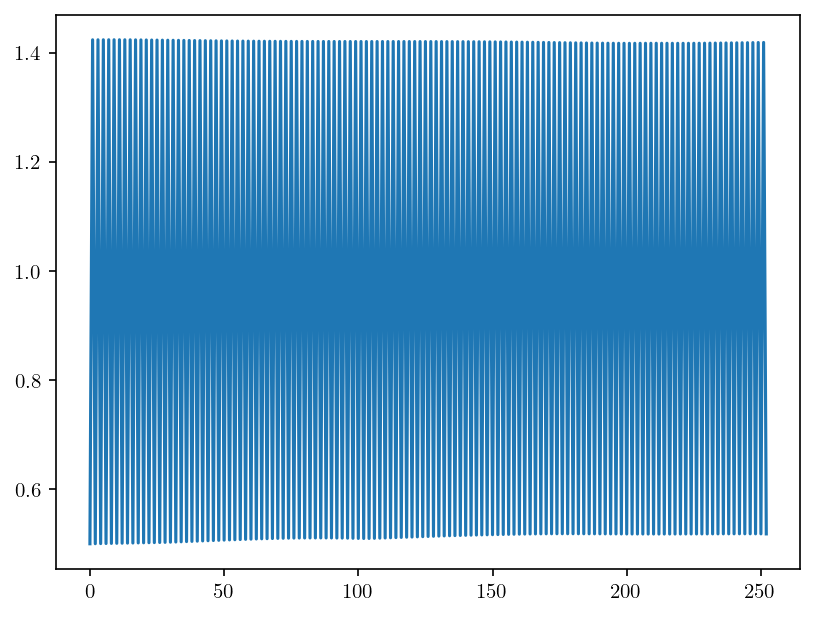

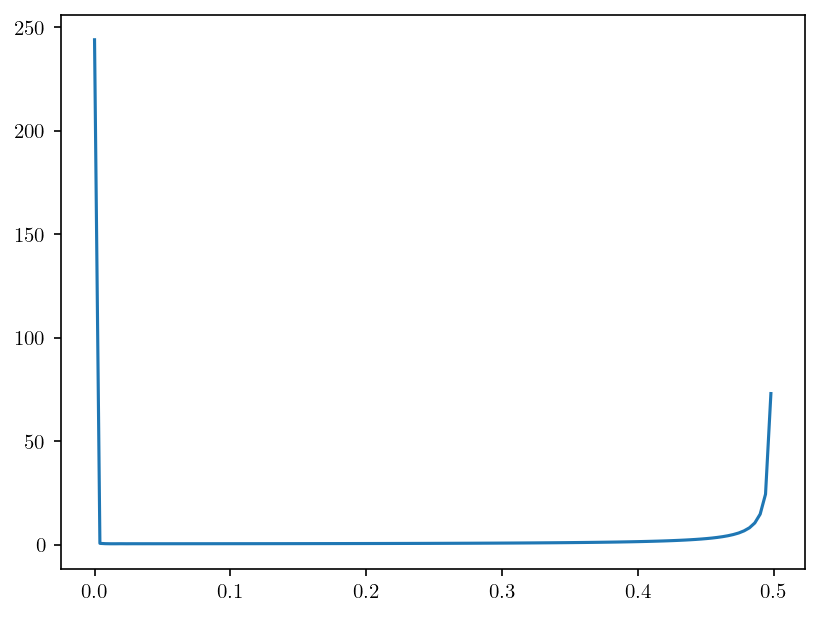

In [8]:
N = 211
steps = int(N * 1.2)
neg = negativity_time_series(N, 0, 0, 0.01, steps = steps, state = coherent_state)
t = np.arange(steps)

plt.plot(t, neg)
plt.show()

# plot power spectrum

fft = np.fft.fft(neg)
omega = np.fft.fftfreq(len(t), np.diff(t)[0])
plt.plot(omega[:len(t)//2 + 1],np.abs(fft[:len(t)//2+1]))
plt.show()

Strucutured analysis with more plots

In [4]:
def run_time_evolution(Ns, alpha, beta, K, state):

    N = len(Ns)

    cols = int(np.ceil(np.sqrt(N)))
    rows = int(np.ceil(N / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for i in range(N):
        Ni = Ns[i]

        steps = int(1.2* Ni)
        time = np.arange(steps)

        neg = negativity_time_series(Ni, alpha, beta, K, steps, state)

        ax = axes[i]
        ax.plot(time, neg, marker='o', markersize=1,
                markerfacecolor='firebrick', markeredgecolor='firebrick',
                label=rf"Steps = {steps}")

        ax.axvline(Ni, ls='--', color='teal', label=rf"$t = N$")
        ax.set_xlabel("Time")
        ax.set_ylabel("Negativity")
        ax.set_title(rf"$N = {Ni}$, $\alpha = {alpha}$, $\beta = {beta}$, $\kappa = {K}$")
        ax.legend()

    # Remove unused subplots
    for j in range(N, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Integrable case

In [5]:
Ns_int = [101, 211, 307, 401]
alpha_int = 0; beta_int = 0
K_int = 0.01

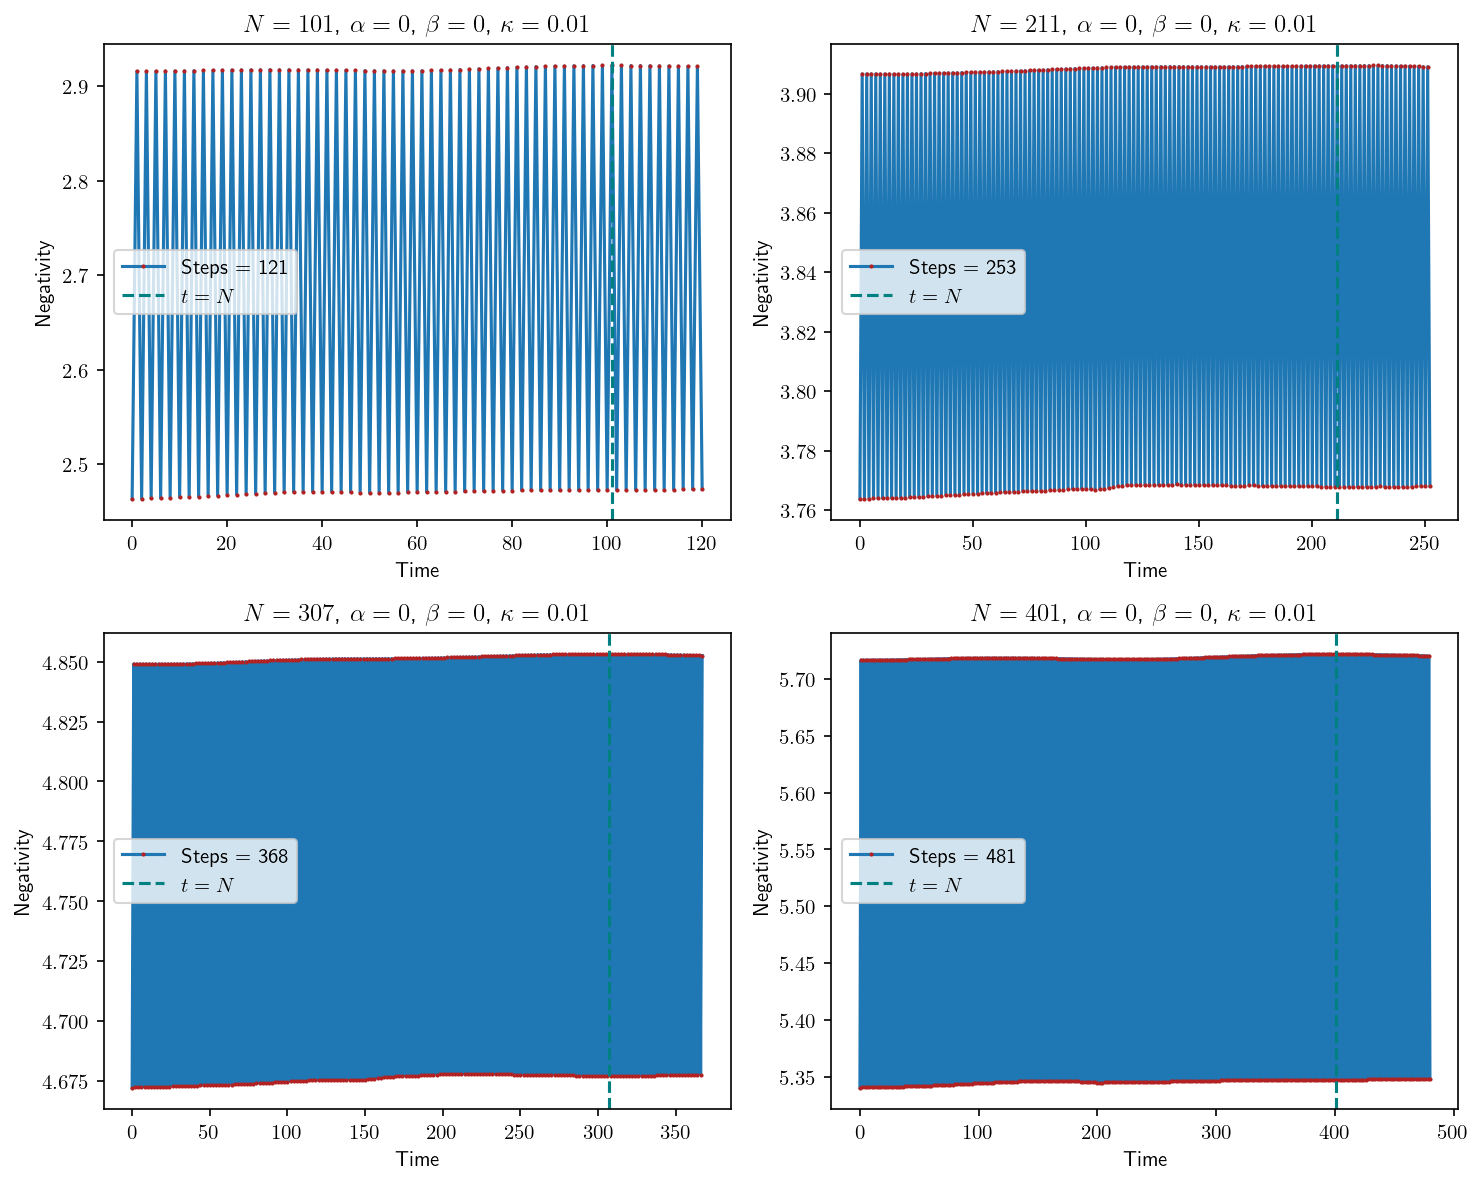

In [6]:
run_time_evolution(Ns_int, alpha_int, beta_int, K_int, localized_state)

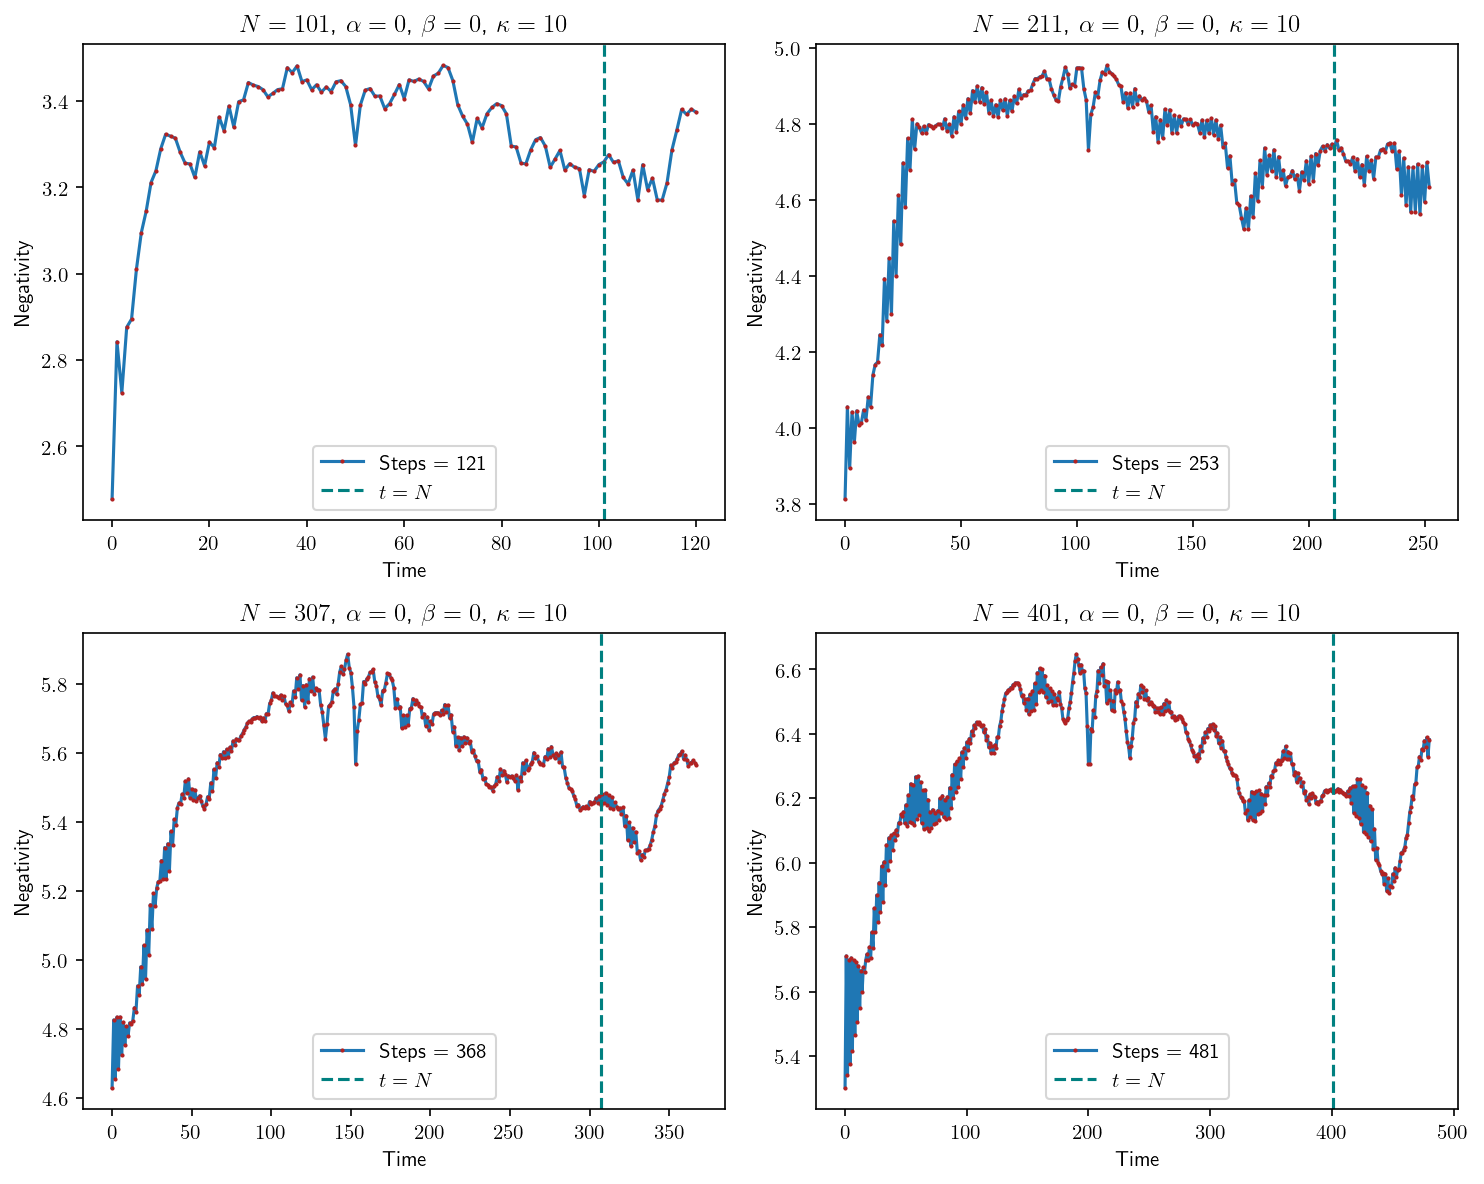

In [7]:
run_time_evolution(Ns_int, 0, 0, 10, localized_state)

  0%|          | 0/6 [00:00<?, ?it/s]

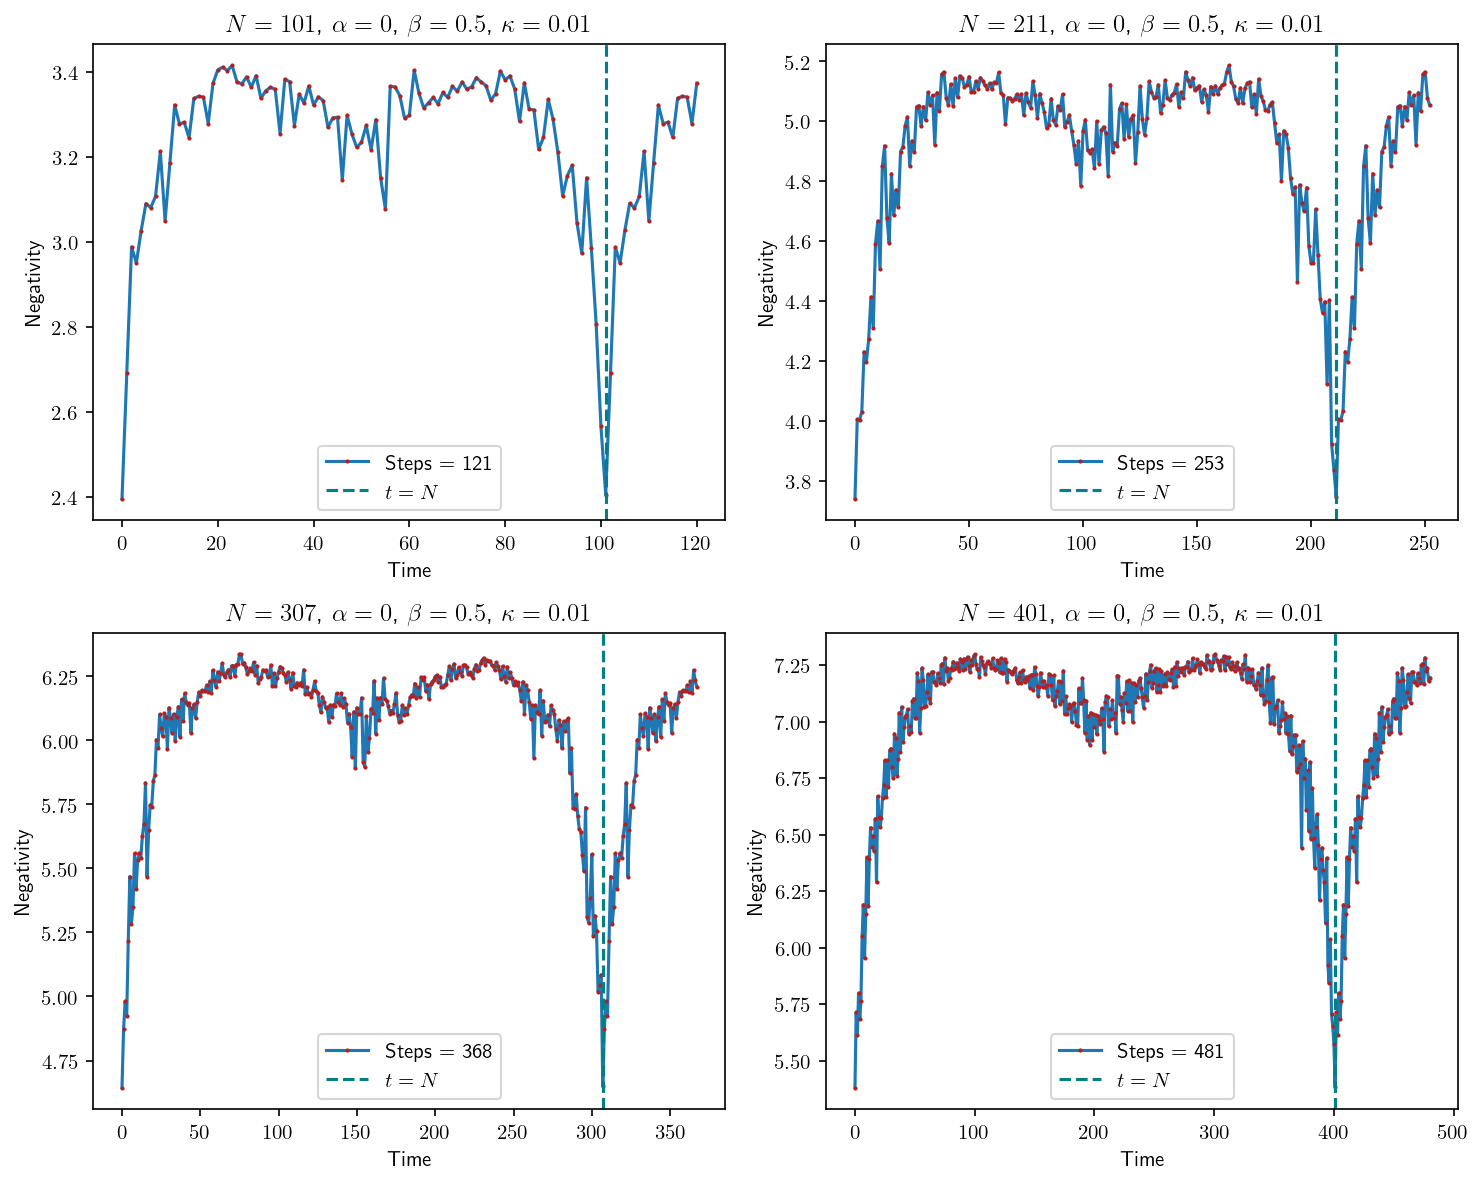

 17%|█▋        | 1/6 [00:09<00:46,  9.33s/it]

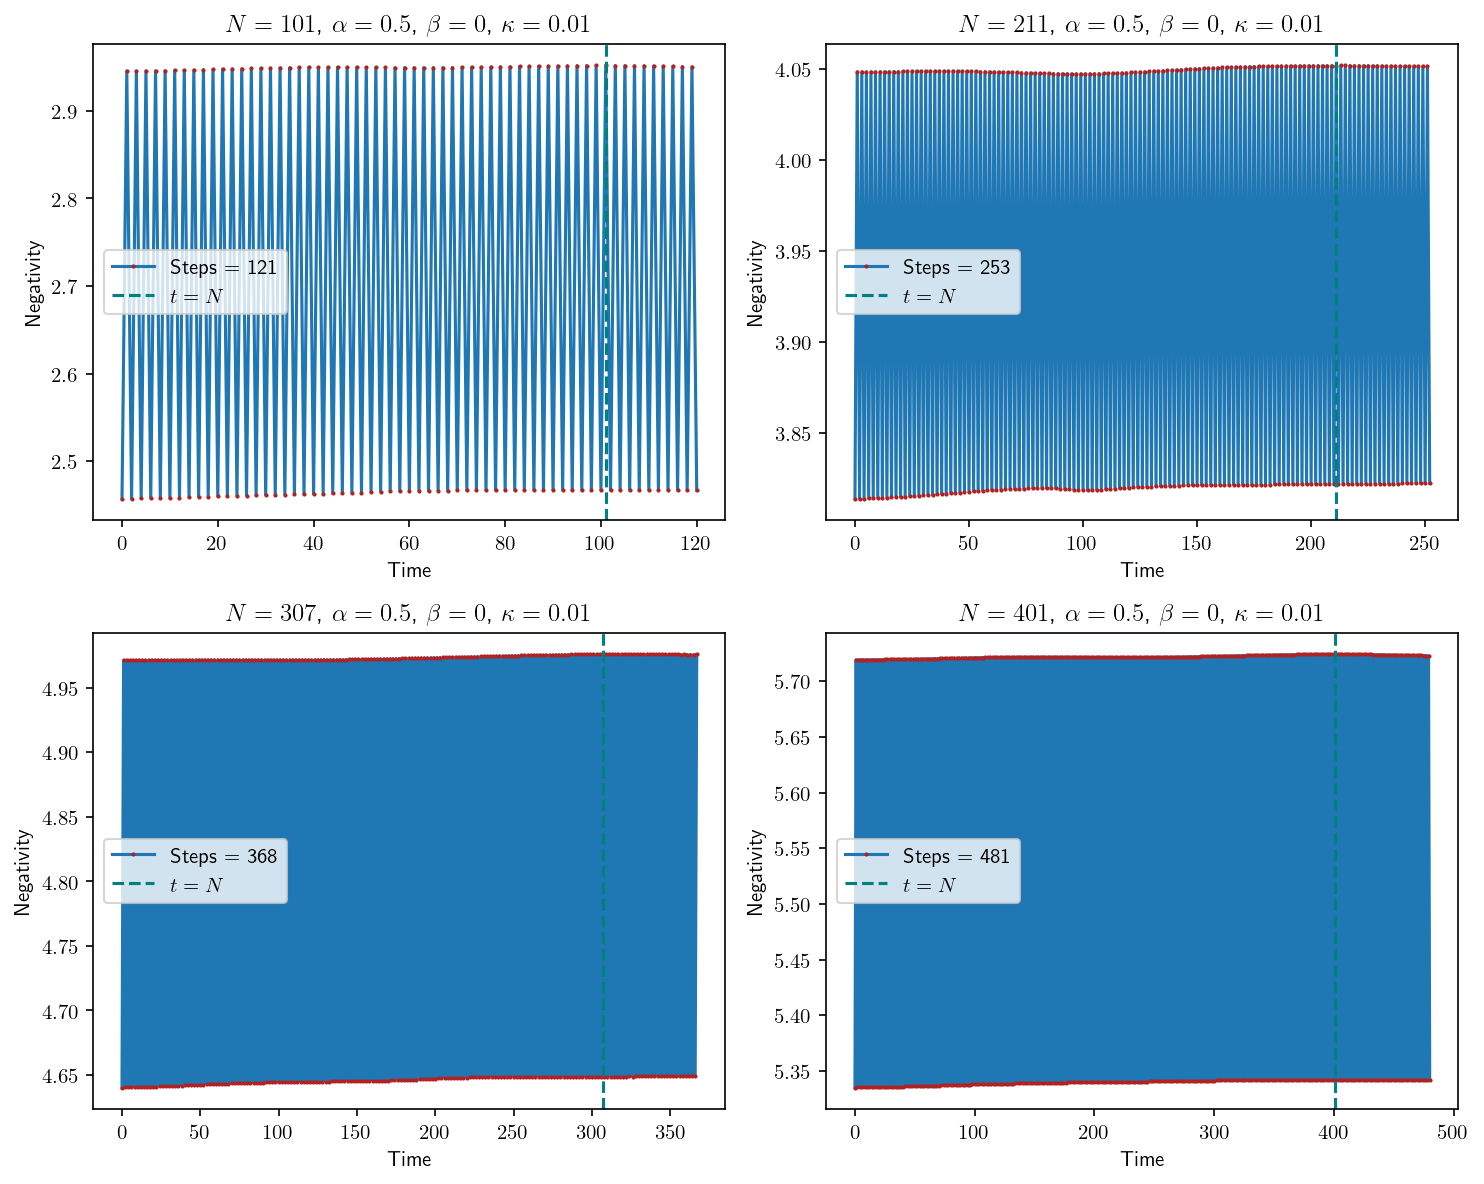

 33%|███▎      | 2/6 [00:18<00:36,  9.24s/it]

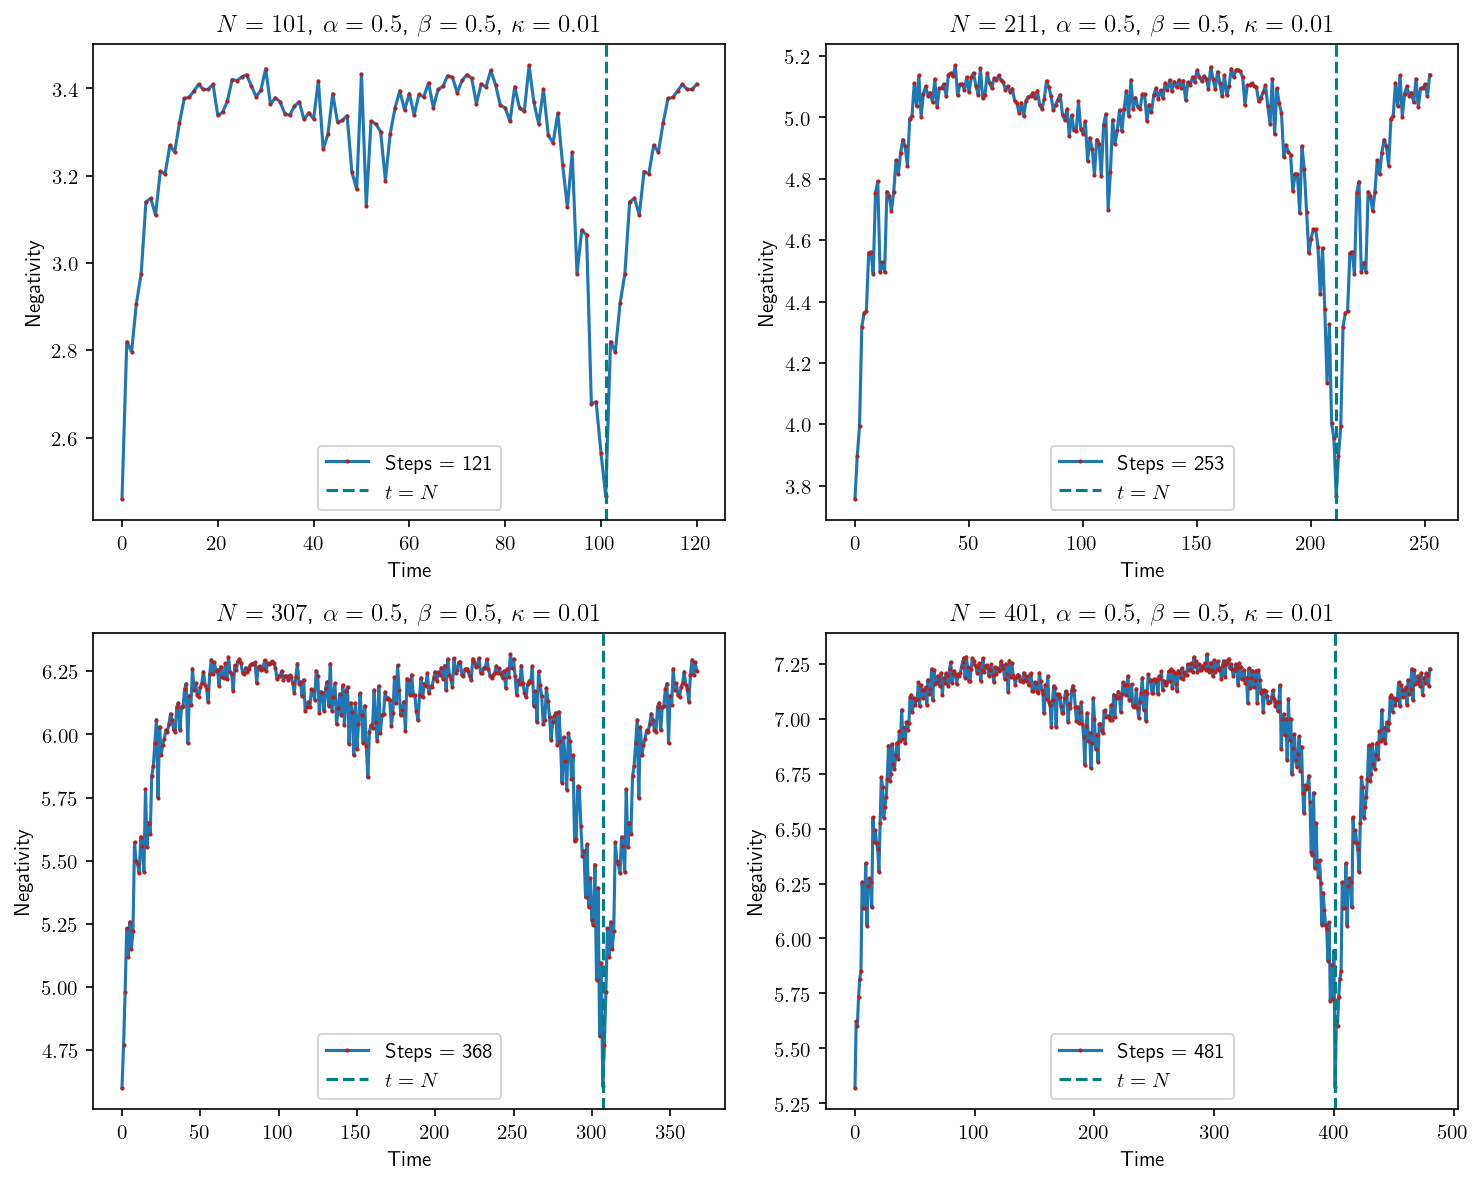

 50%|█████     | 3/6 [00:27<00:27,  9.18s/it]

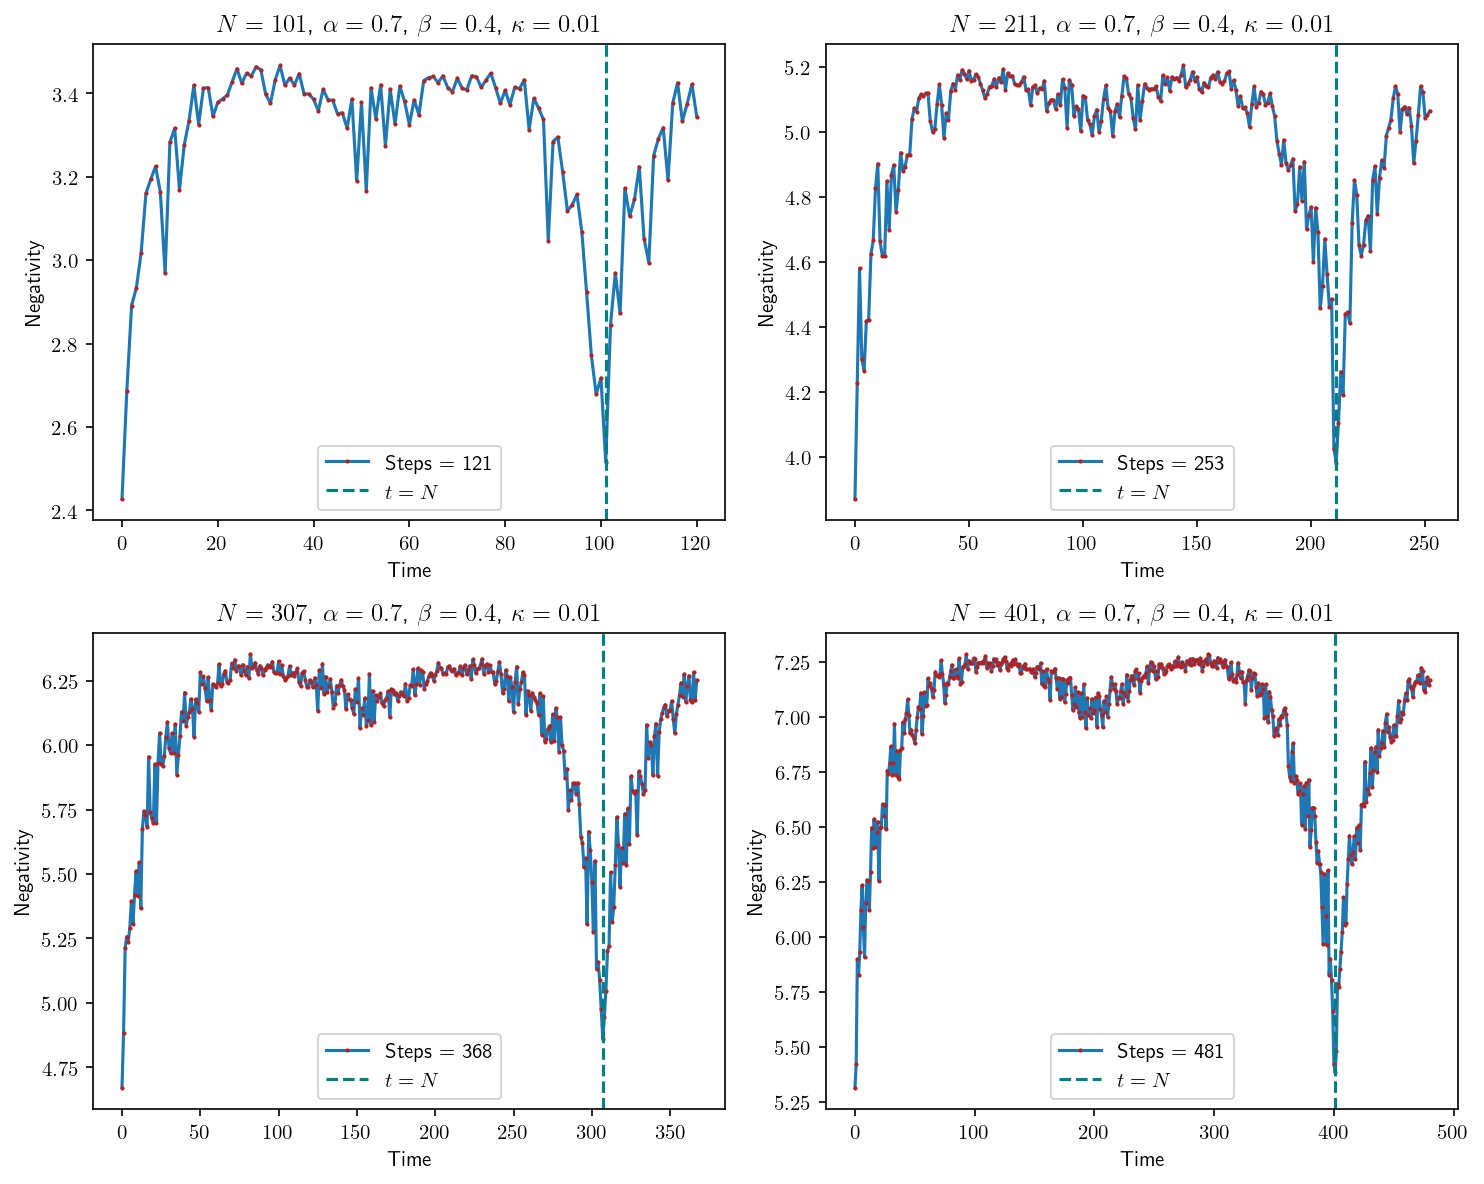

 67%|██████▋   | 4/6 [00:36<00:18,  9.22s/it]

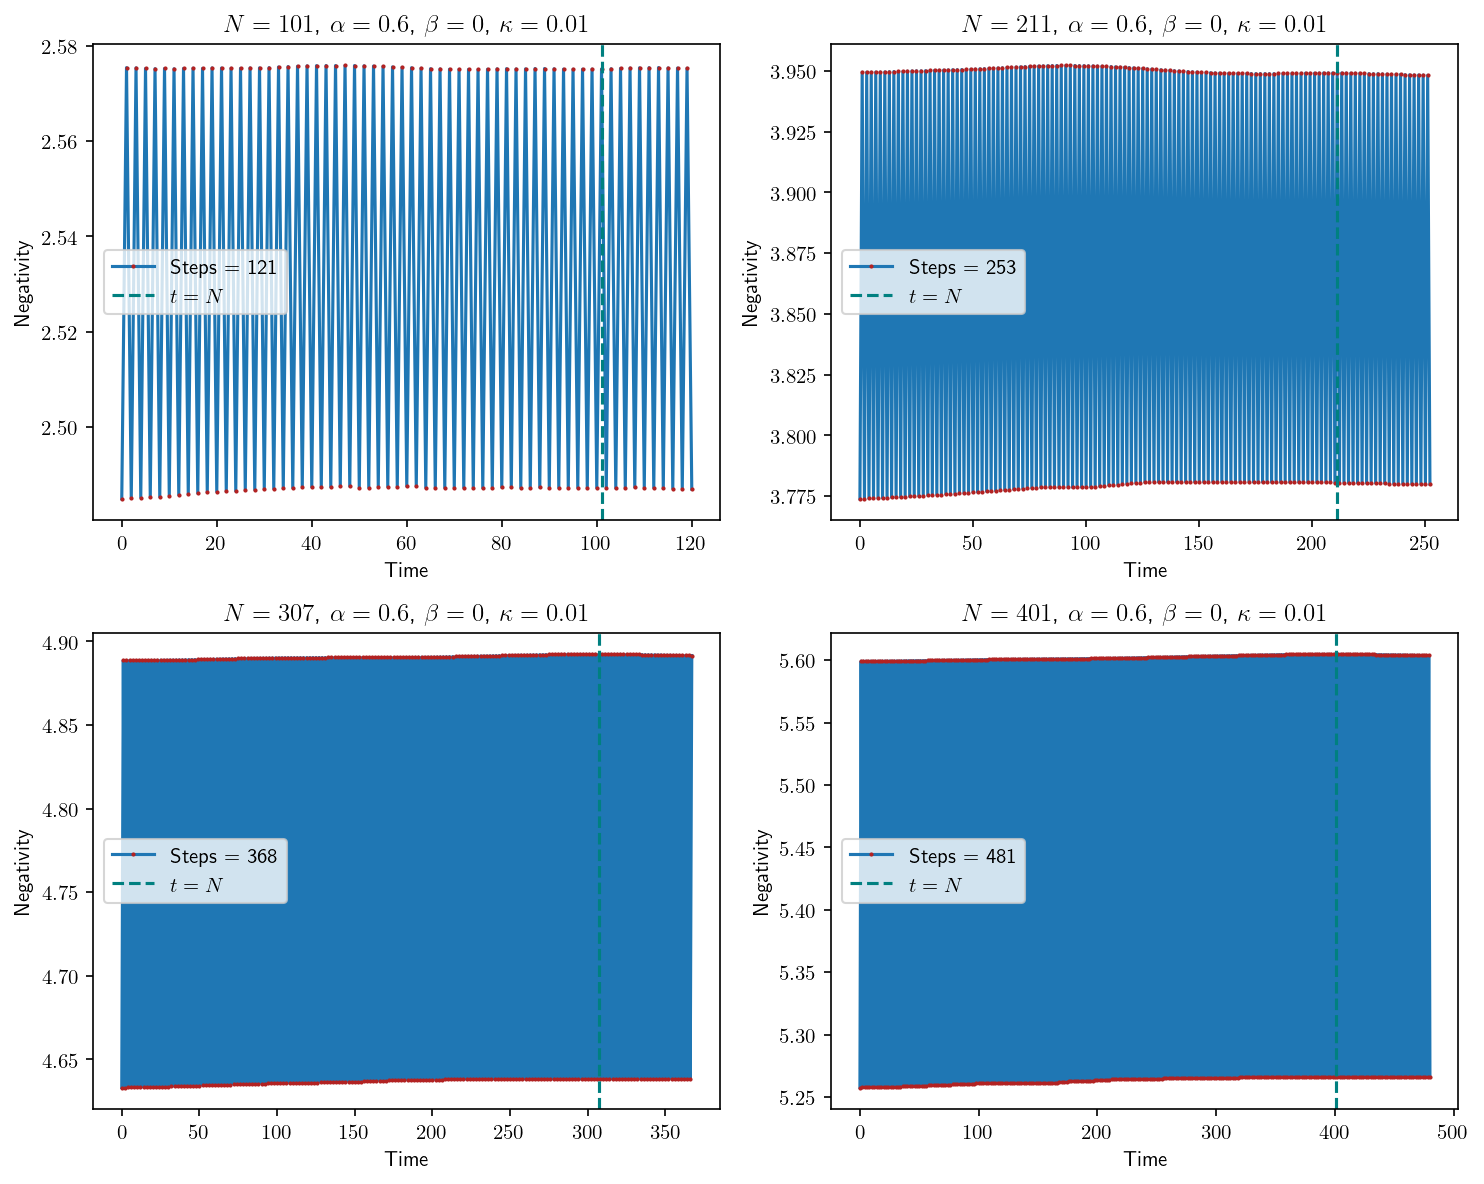

 83%|████████▎ | 5/6 [00:45<00:09,  9.16s/it]

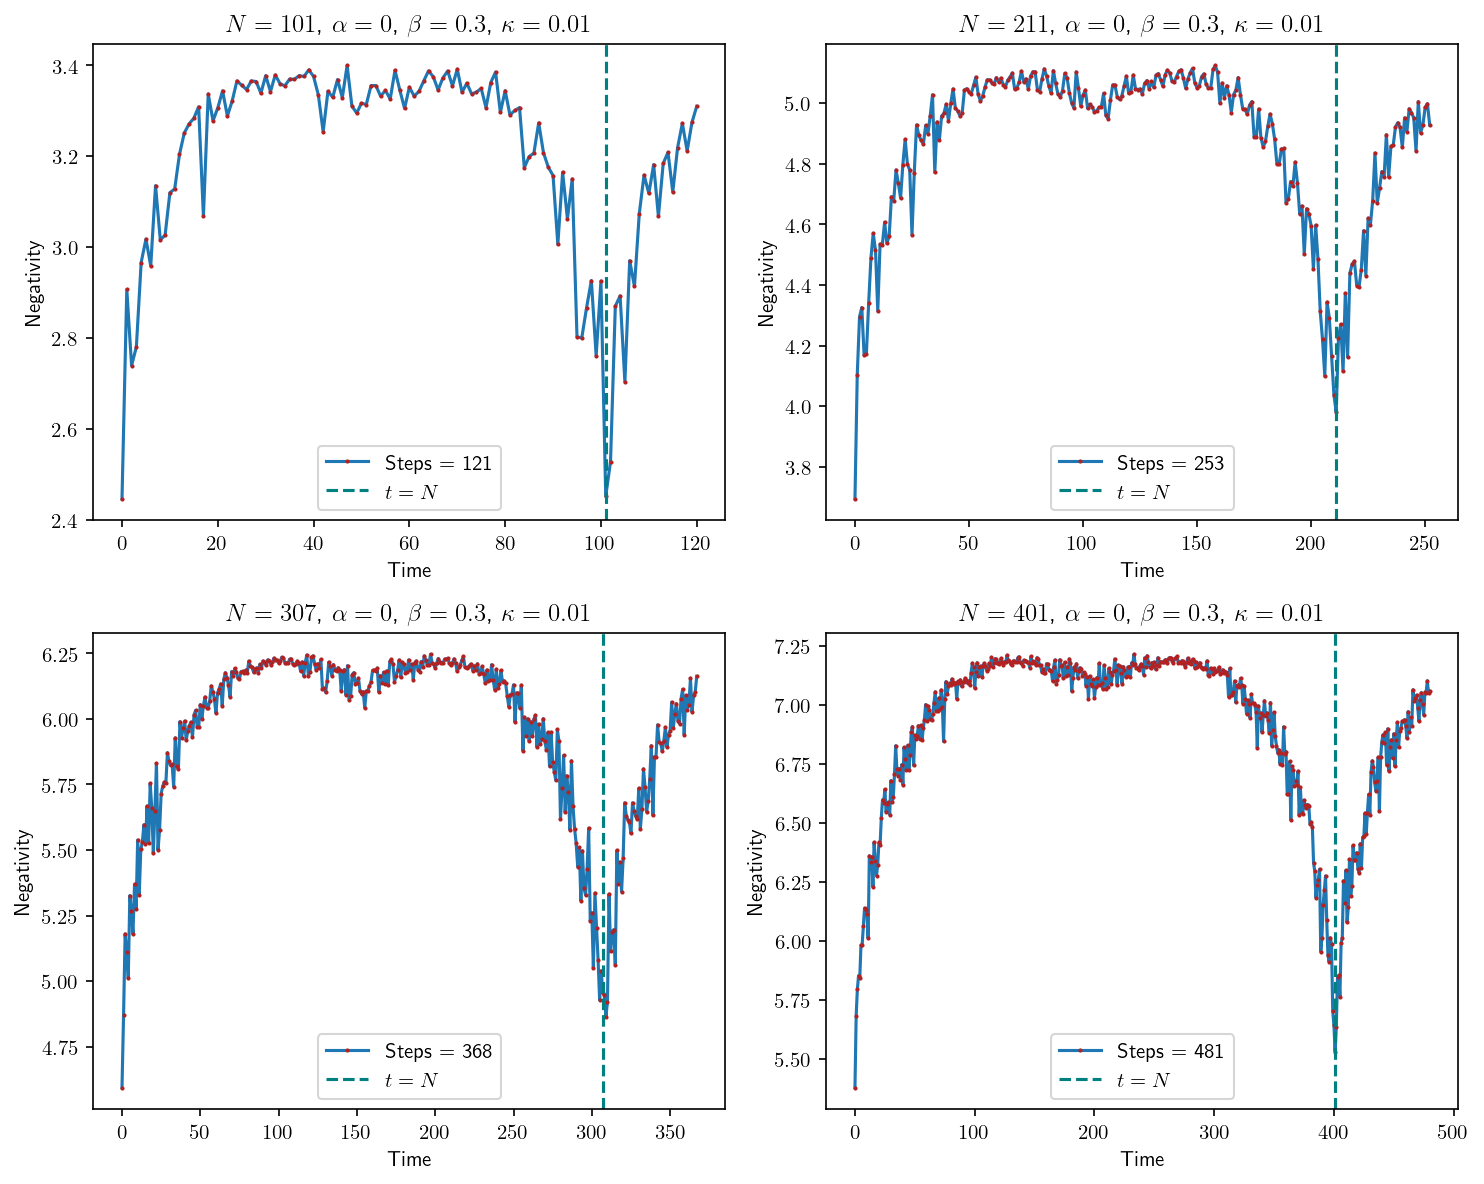

  0%|          | 0/6 [00:00<?, ?it/s]

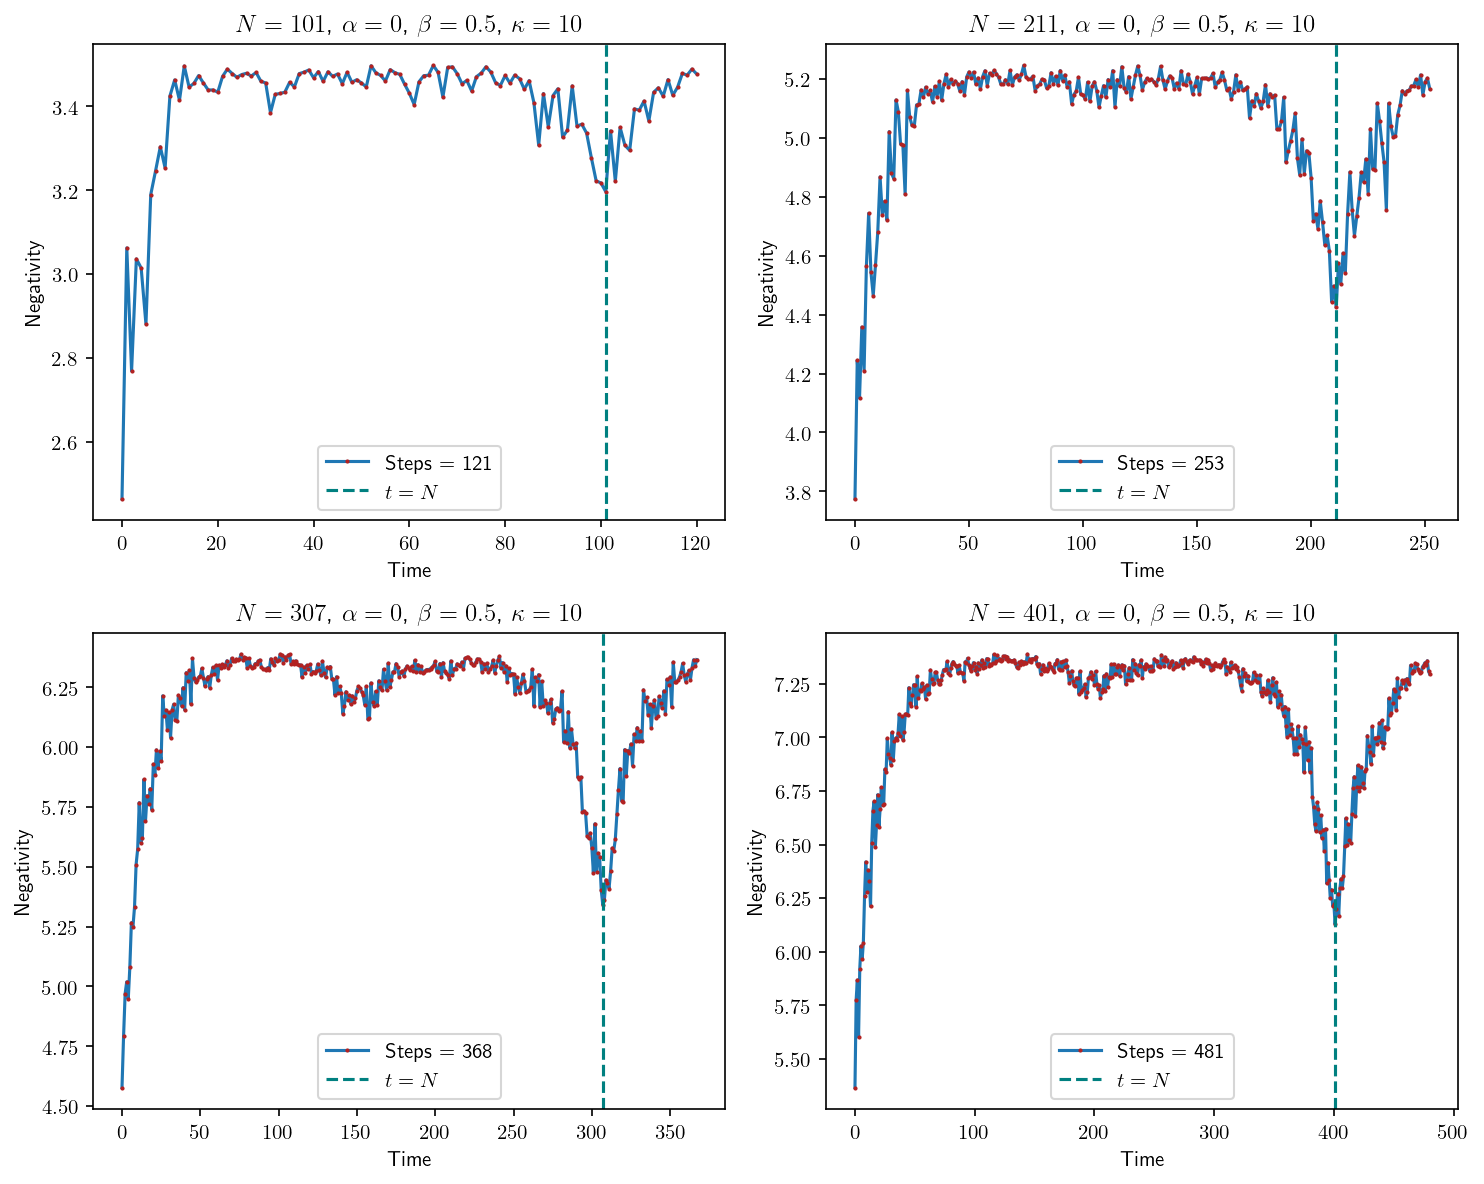

 17%|█▋        | 1/6 [00:08<00:44,  8.99s/it]

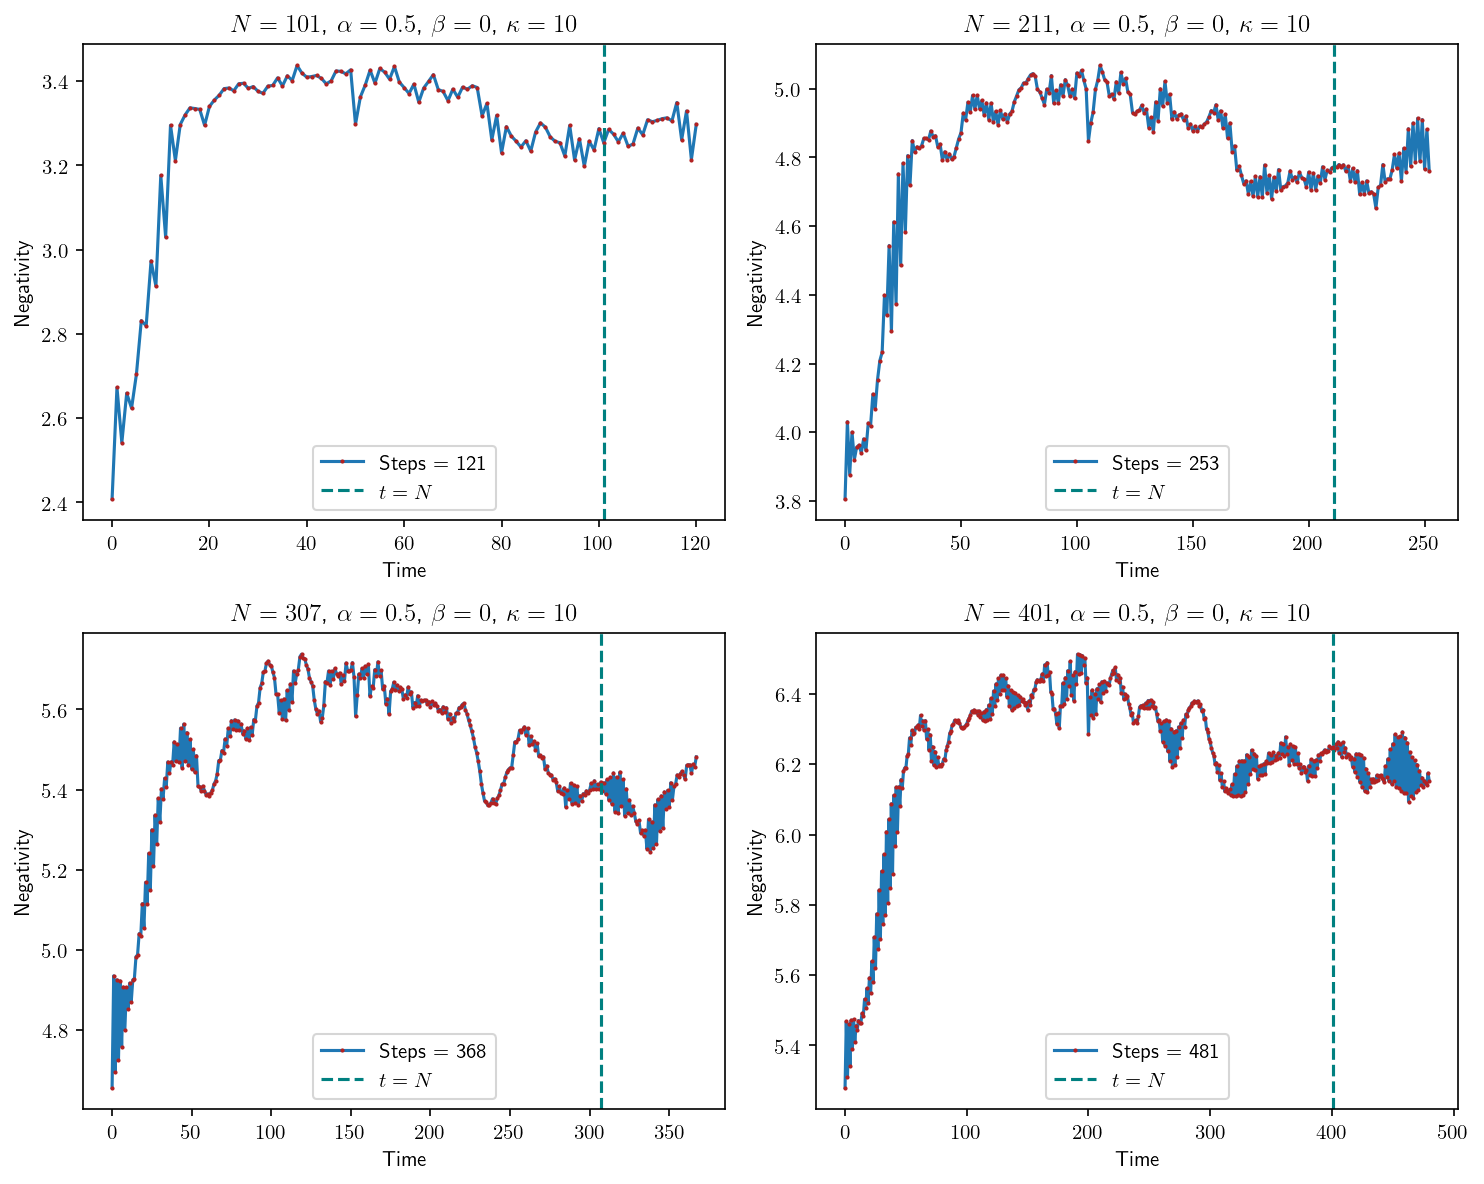

 33%|███▎      | 2/6 [00:18<00:36,  9.05s/it]

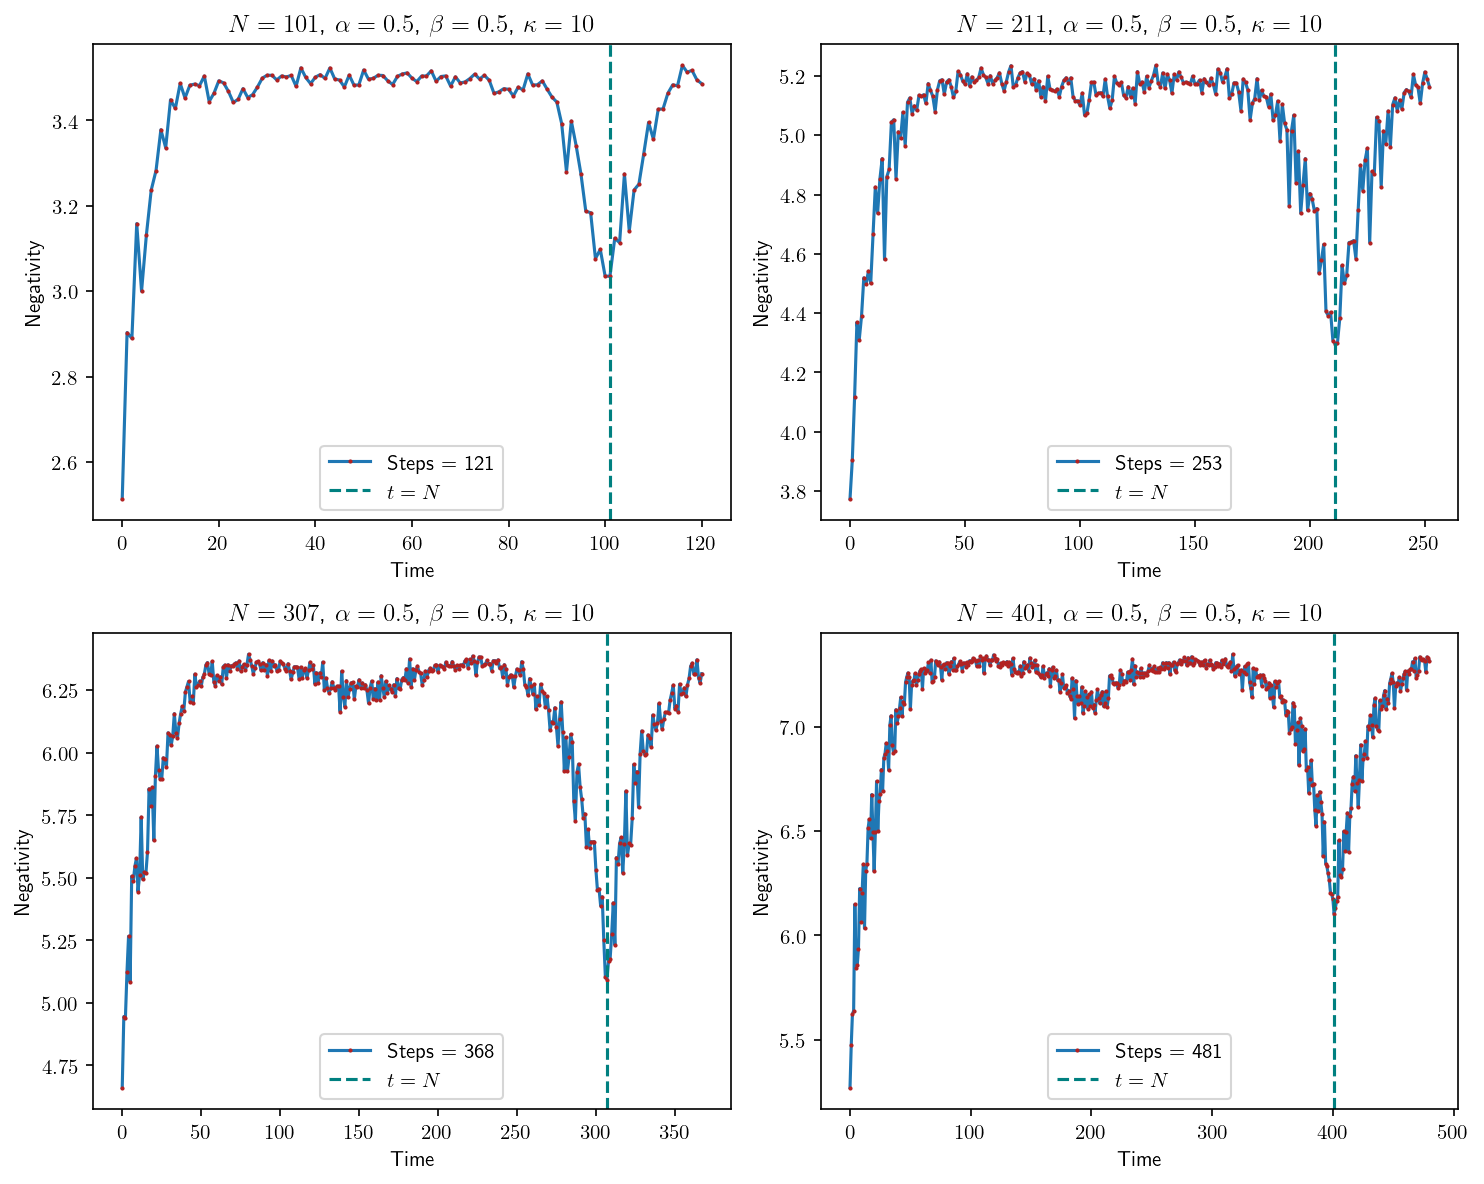

 50%|█████     | 3/6 [00:27<00:27,  9.05s/it]

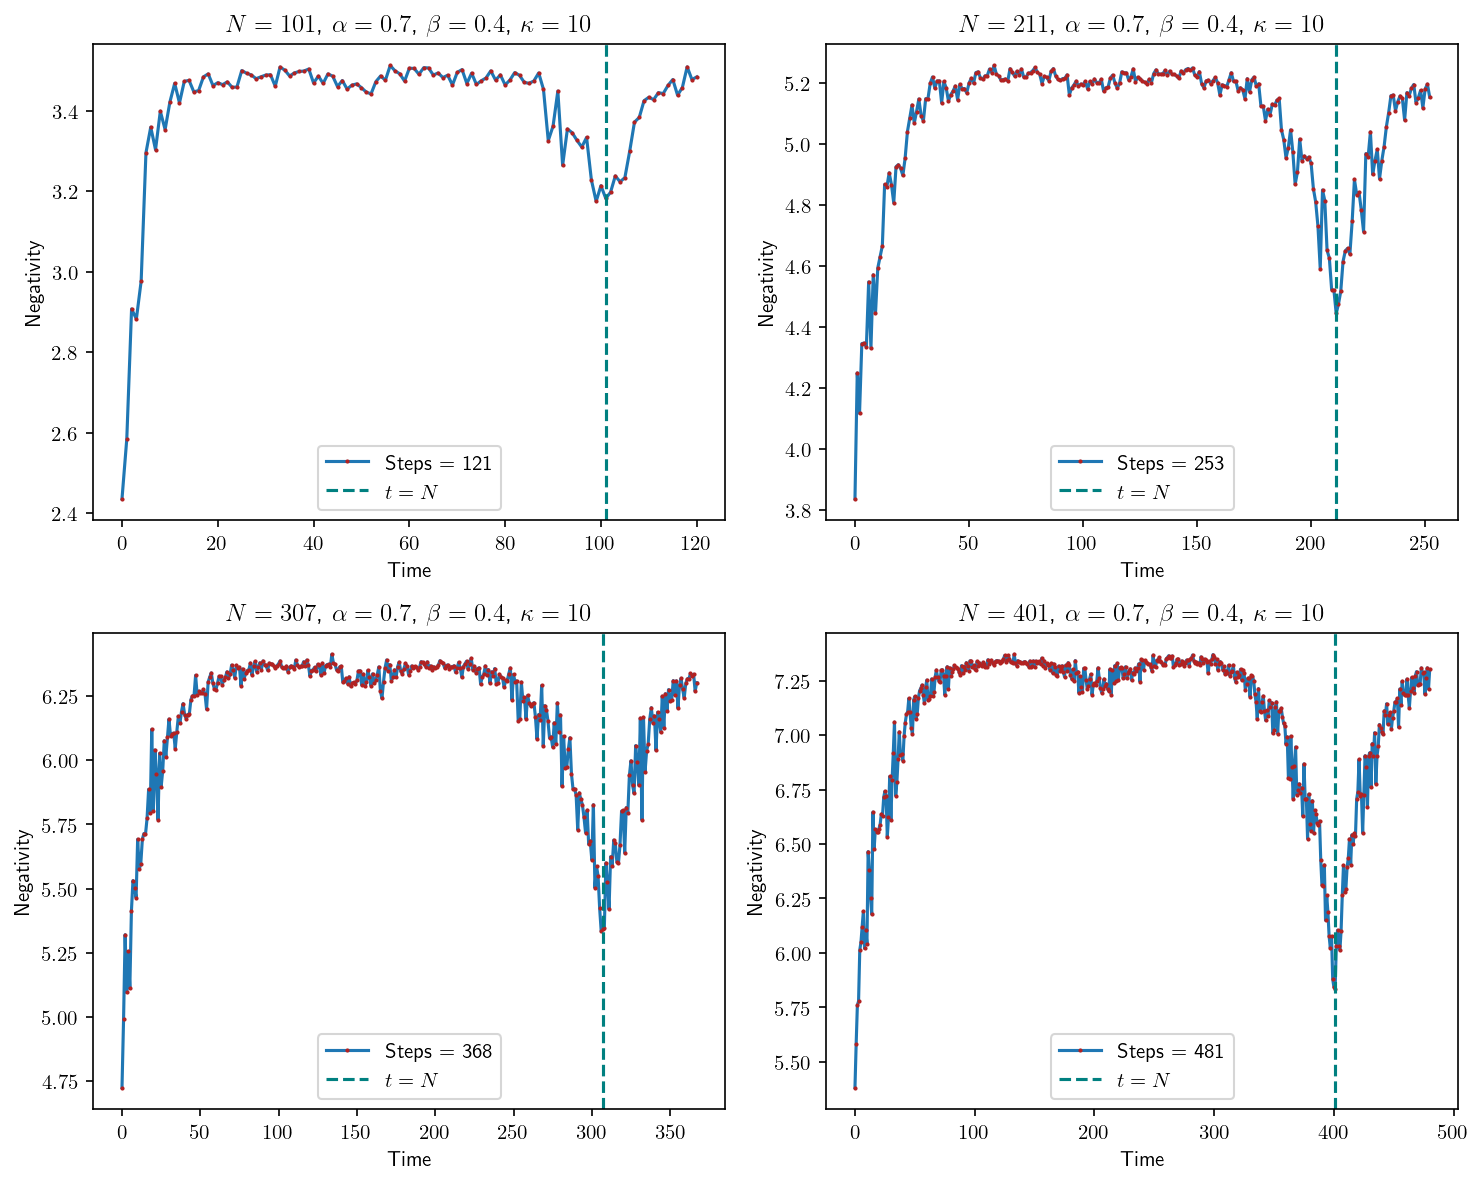

 67%|██████▋   | 4/6 [00:36<00:18,  9.06s/it]

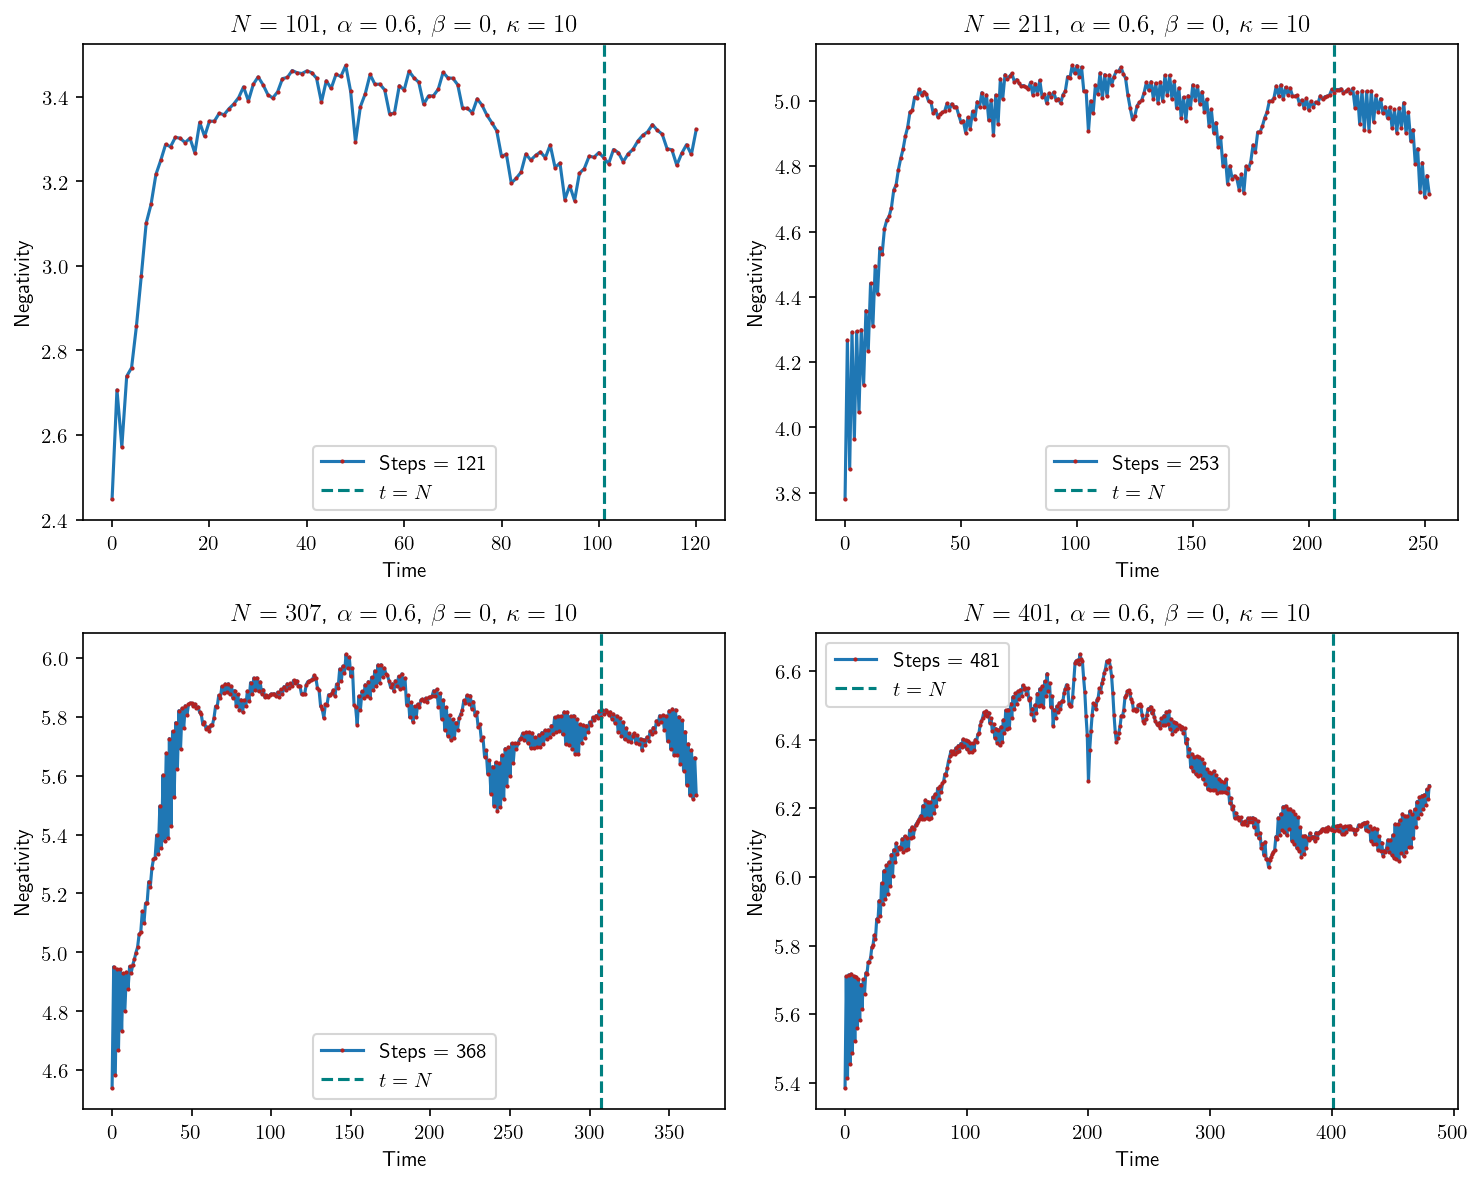

 83%|████████▎ | 5/6 [00:45<00:09,  9.06s/it]

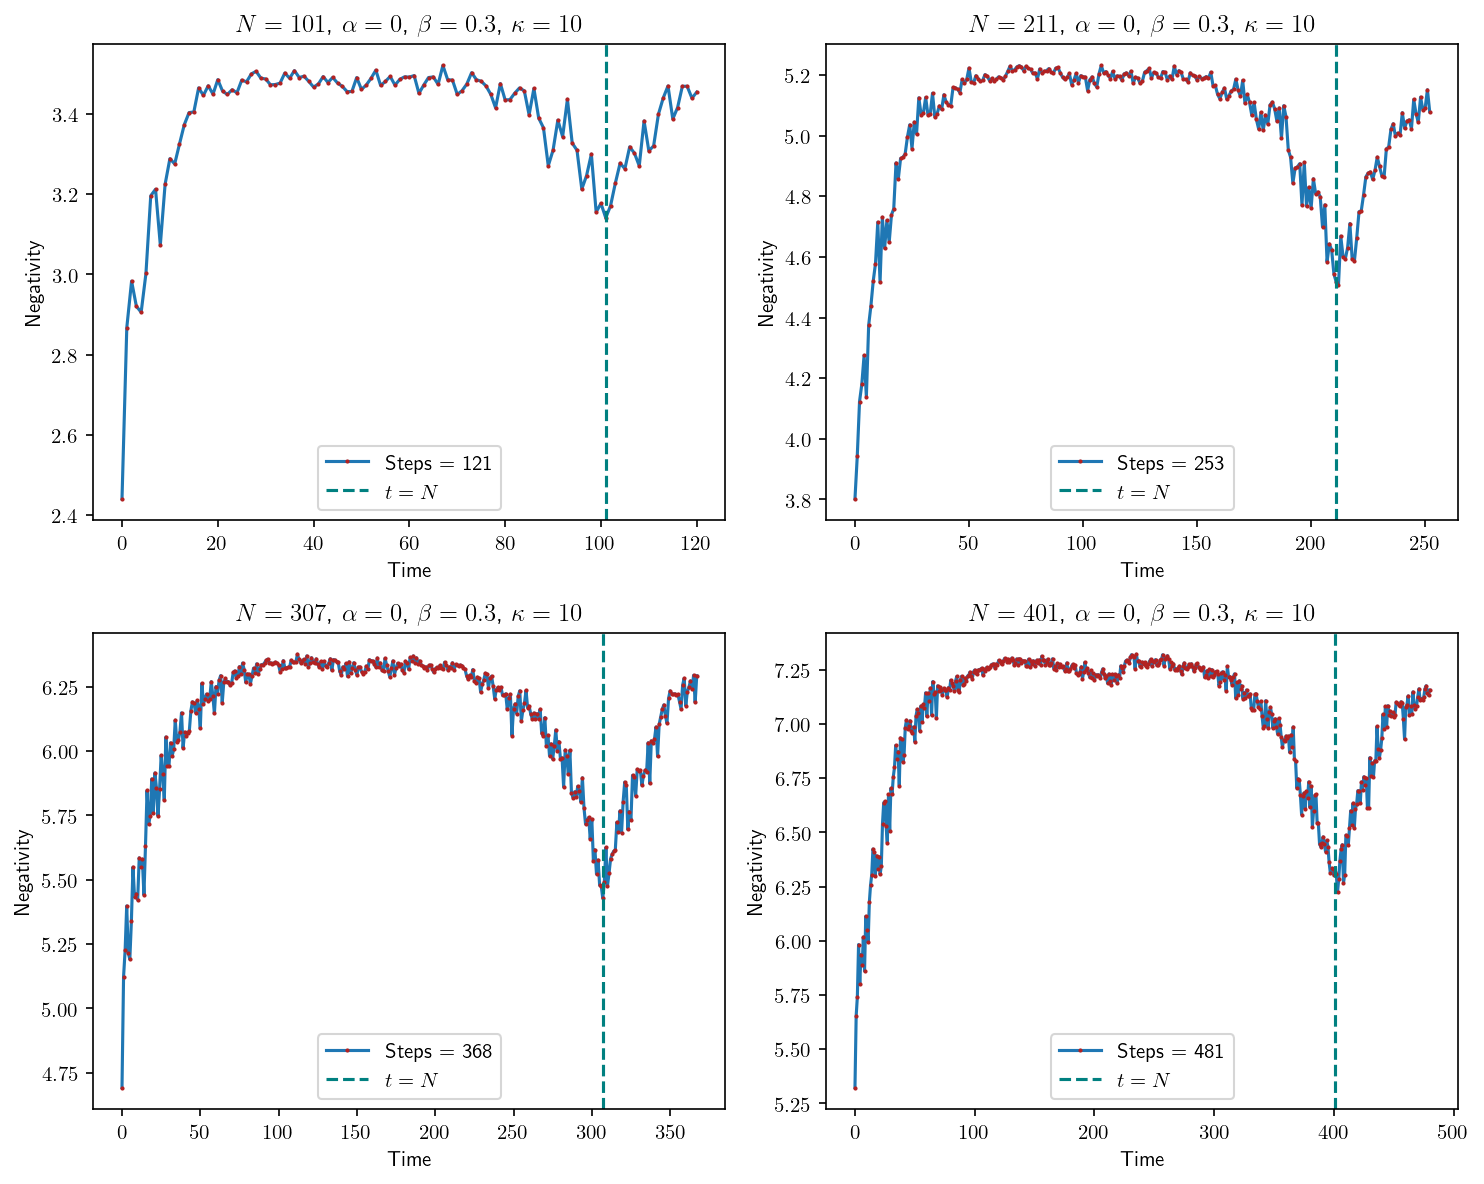

100%|██████████| 6/6 [00:54<00:00,  9.05s/it]


In [8]:
sym_pars = [(0, 0.5), (0.5, 0), (0.5, 0.5), (0.7, 0.4), (0.6, 0), (0, 0.3)]
K_int = 0.01

for pars in tqdm(sym_pars):
    alpha, beta = pars
    run_time_evolution(Ns_int, alpha, beta, 0.01, localized_state)

for pars in tqdm(sym_pars):
    alpha, beta = pars
    run_time_evolution(Ns_int, alpha, beta, 10, localized_state)

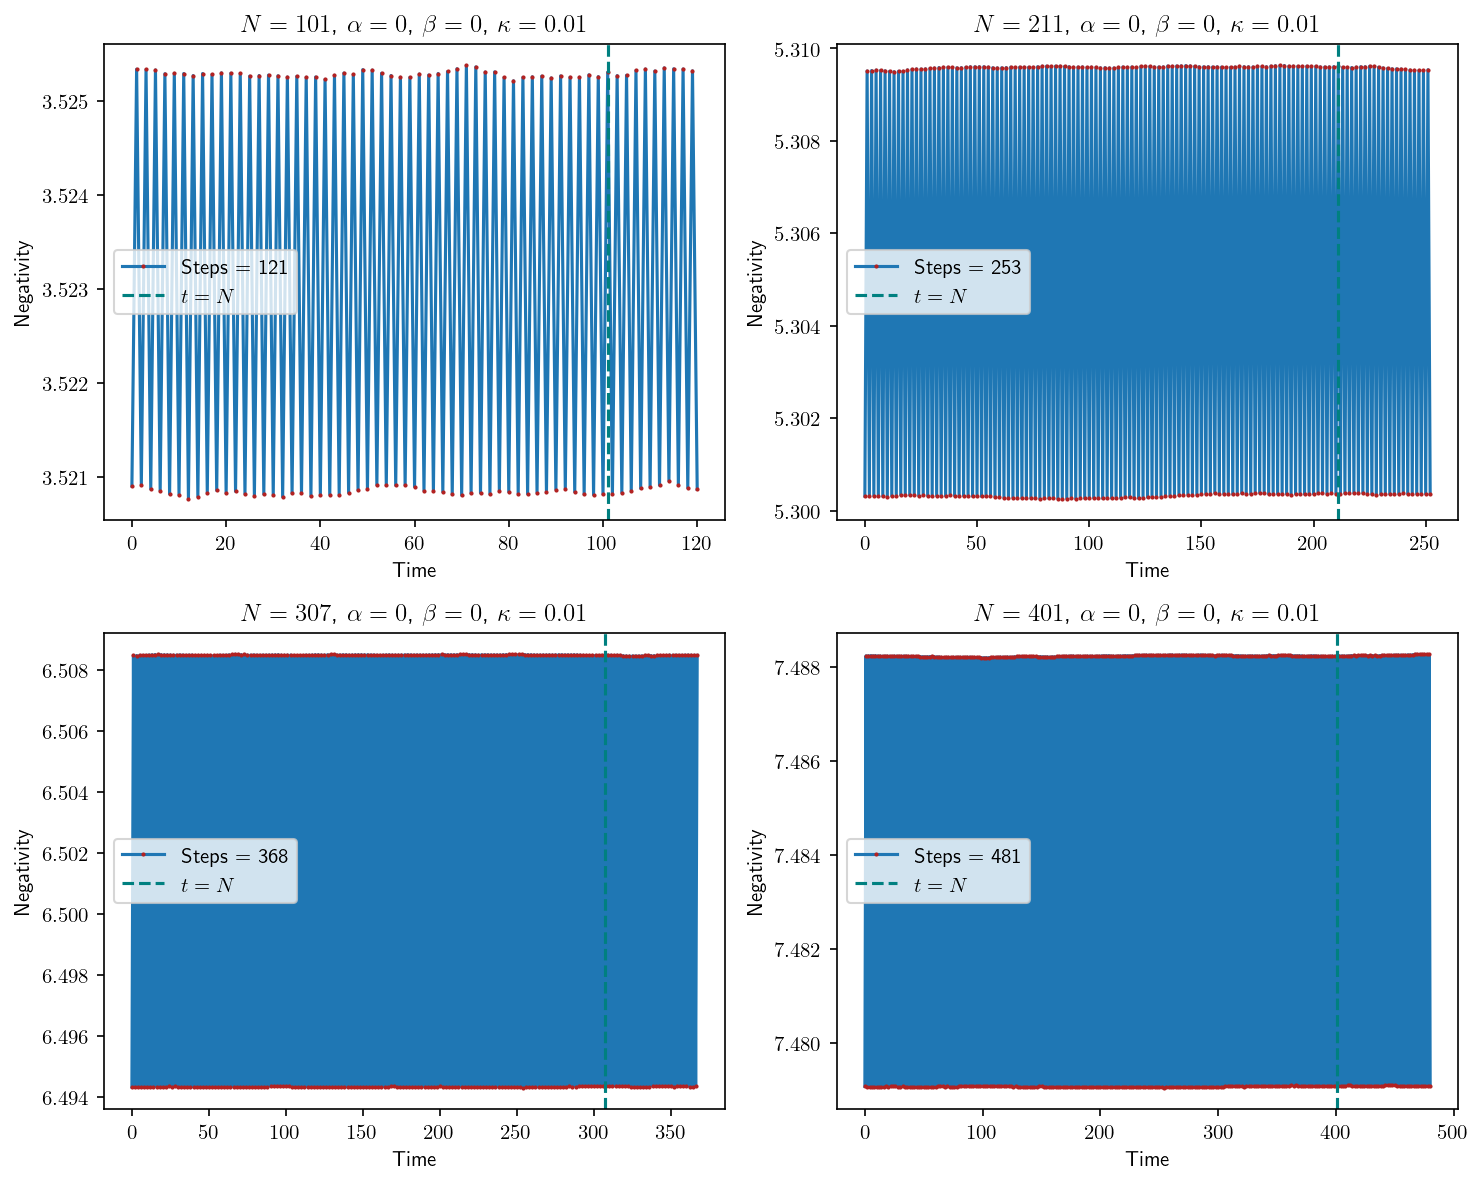

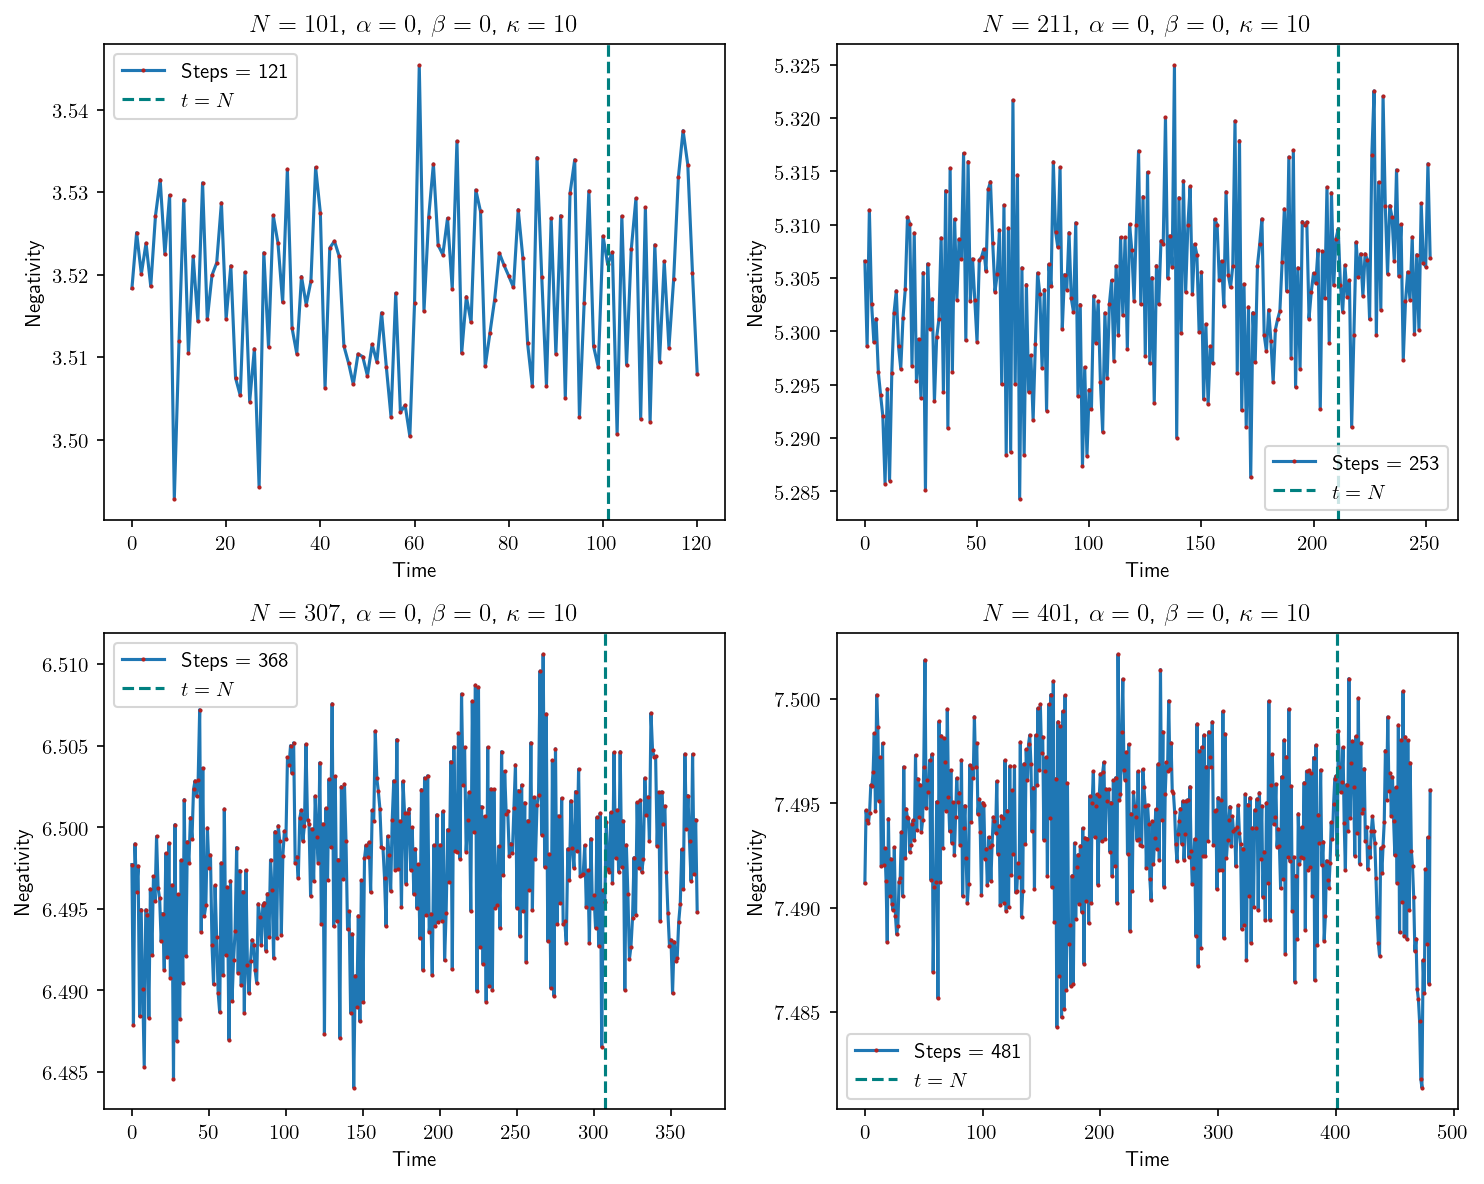

In [9]:
run_time_evolution(Ns_int, alpha_int, beta_int, K_int, random_state)
run_time_evolution(Ns_int, alpha_int, beta_int, 10, random_state)

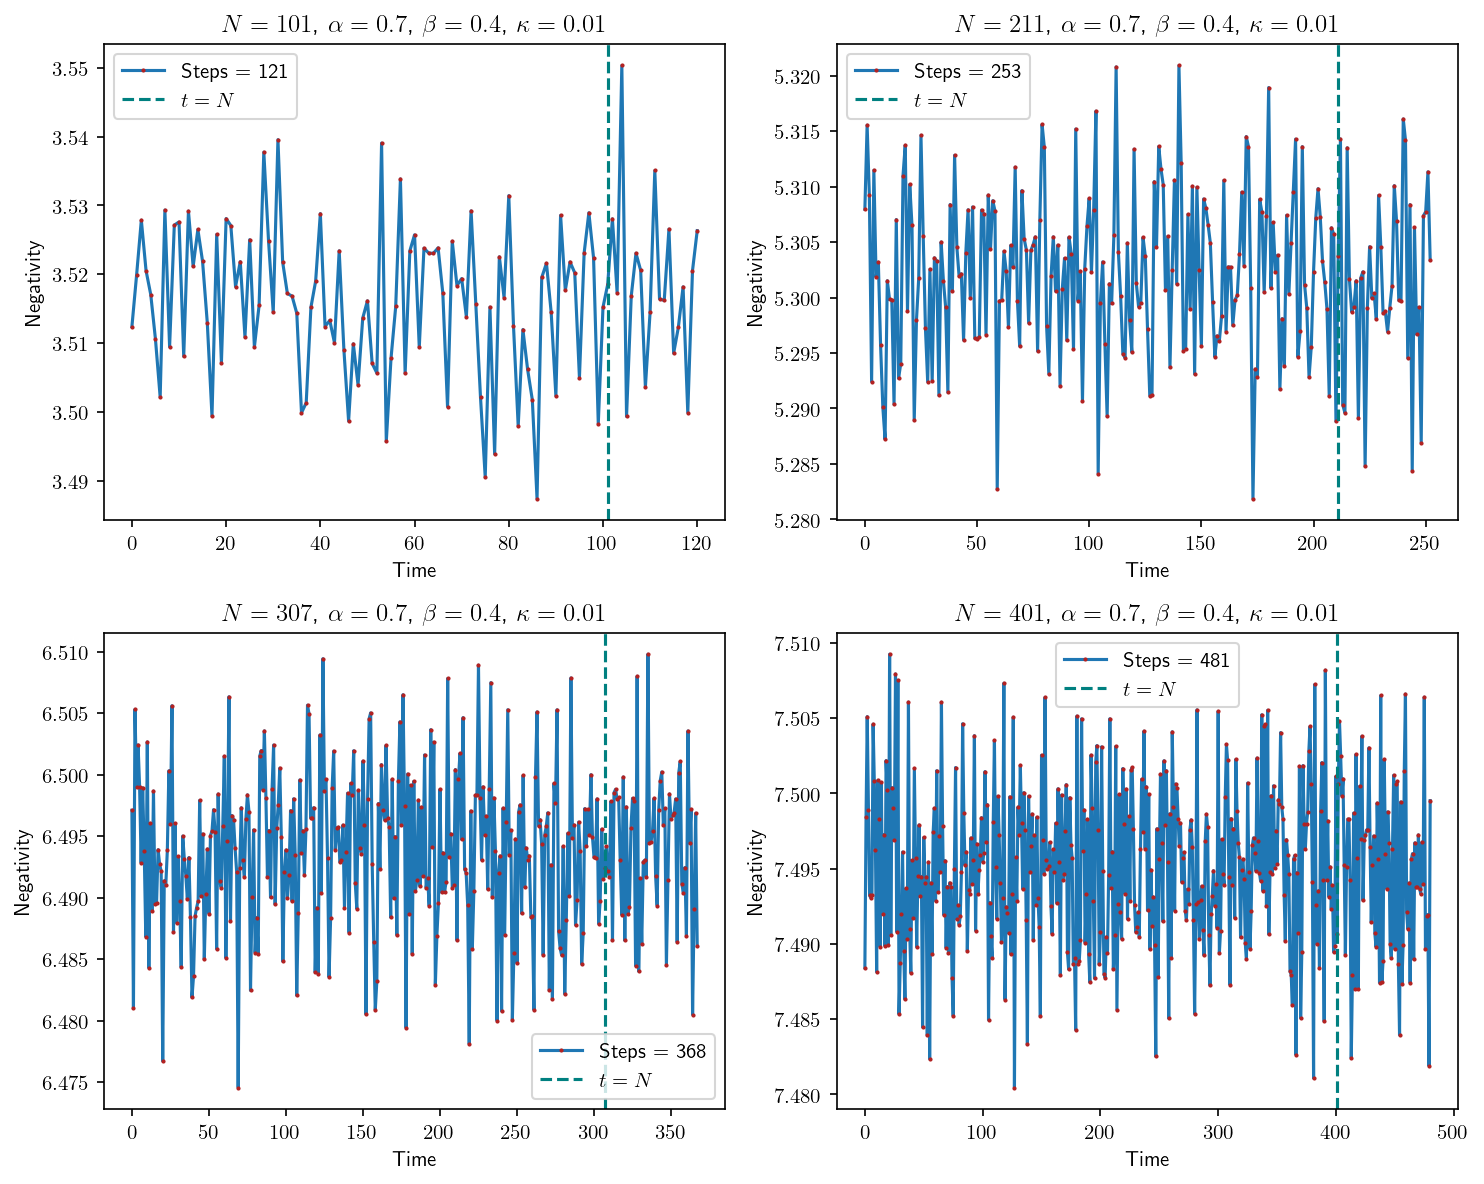

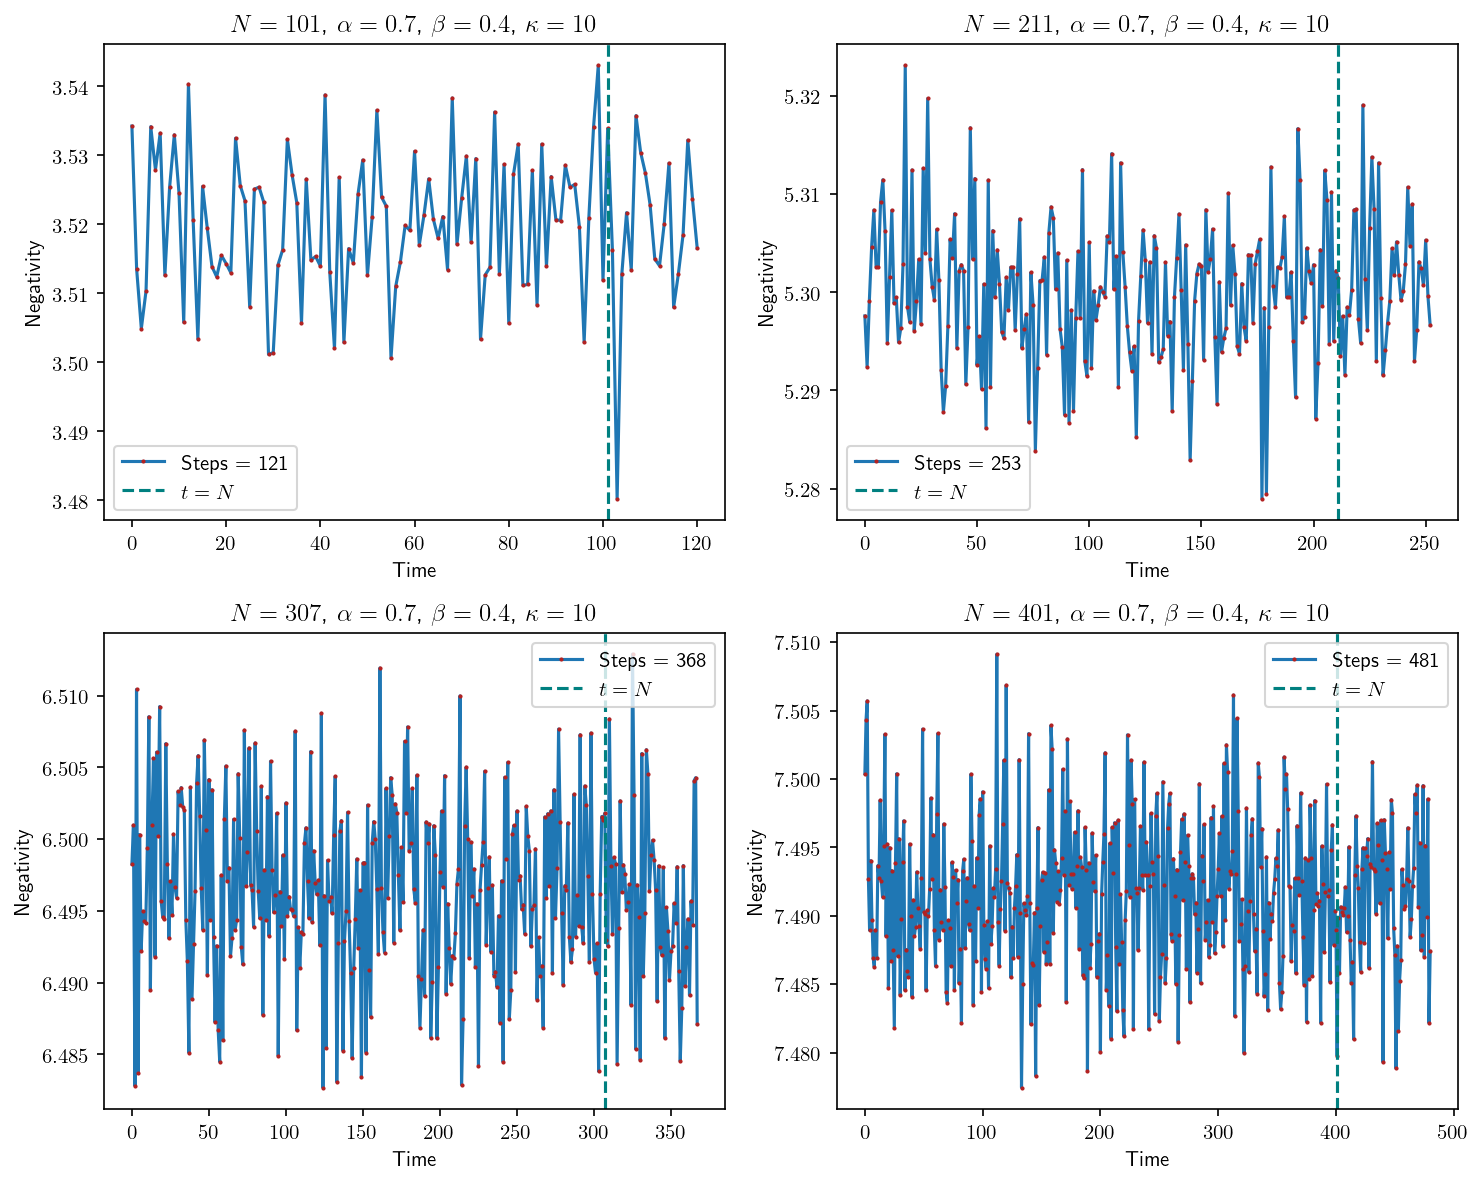

In [10]:
run_time_evolution(Ns_int, 0.7, 0.4, K_int, random_state)
run_time_evolution(Ns_int, 0.7, 0.4, 10, random_state)

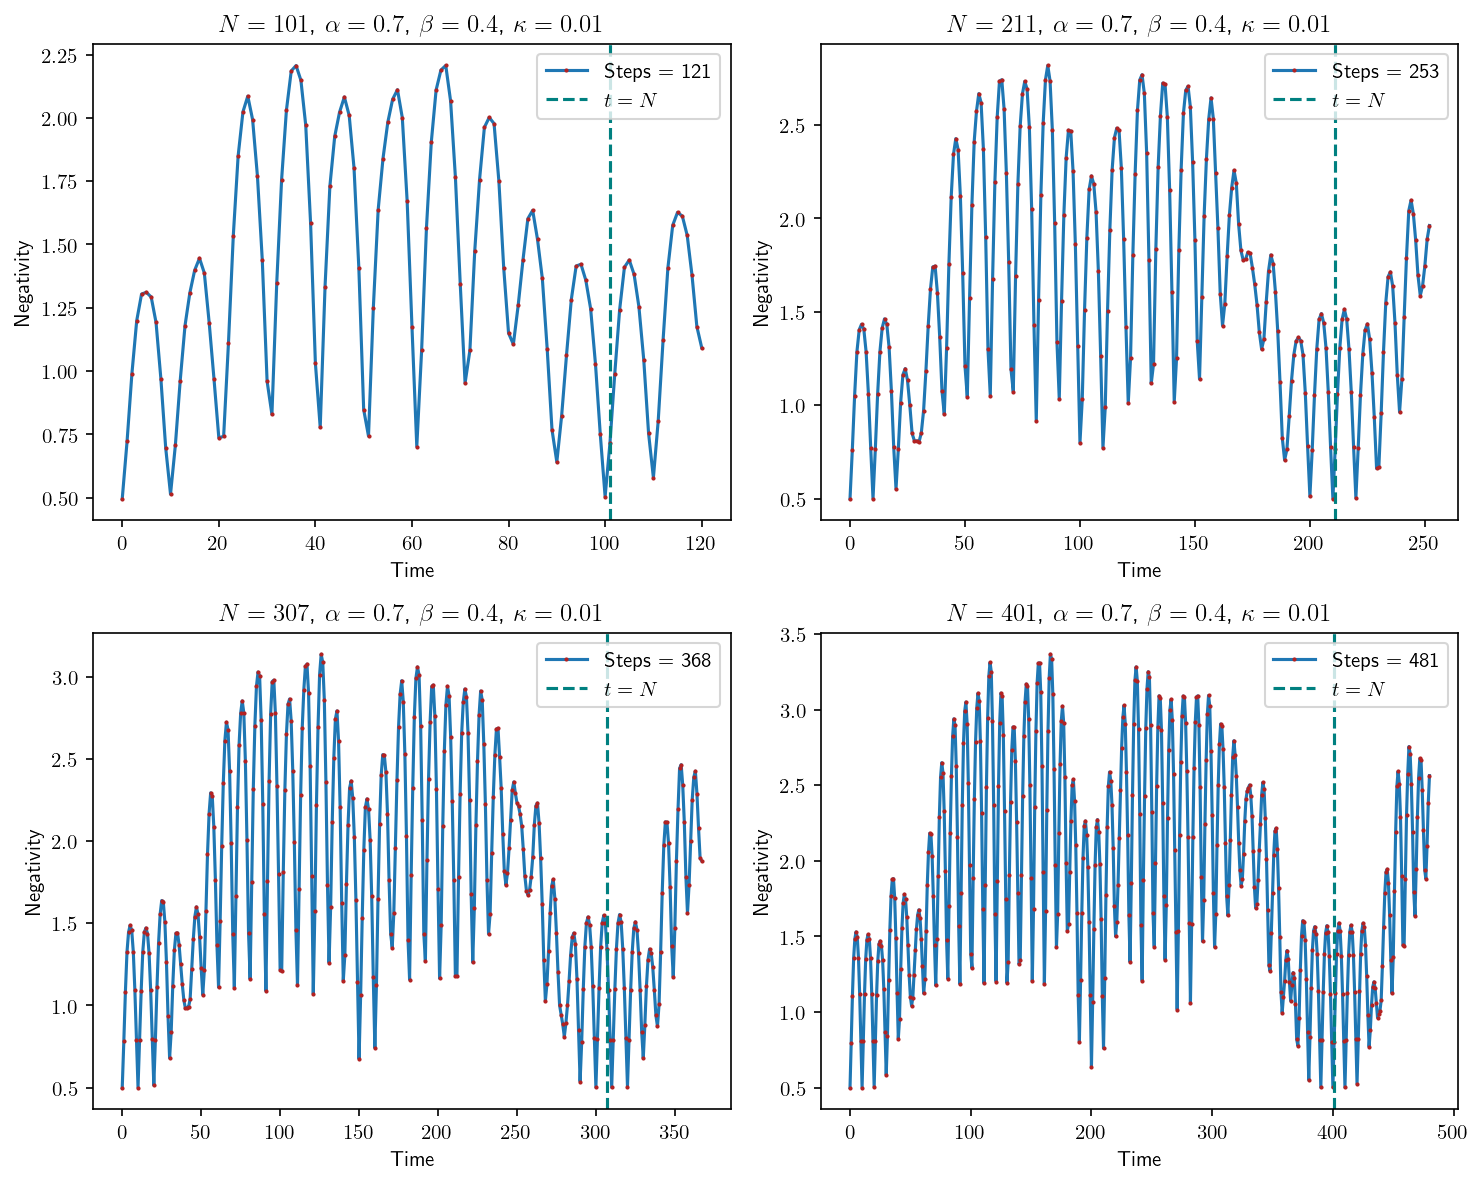

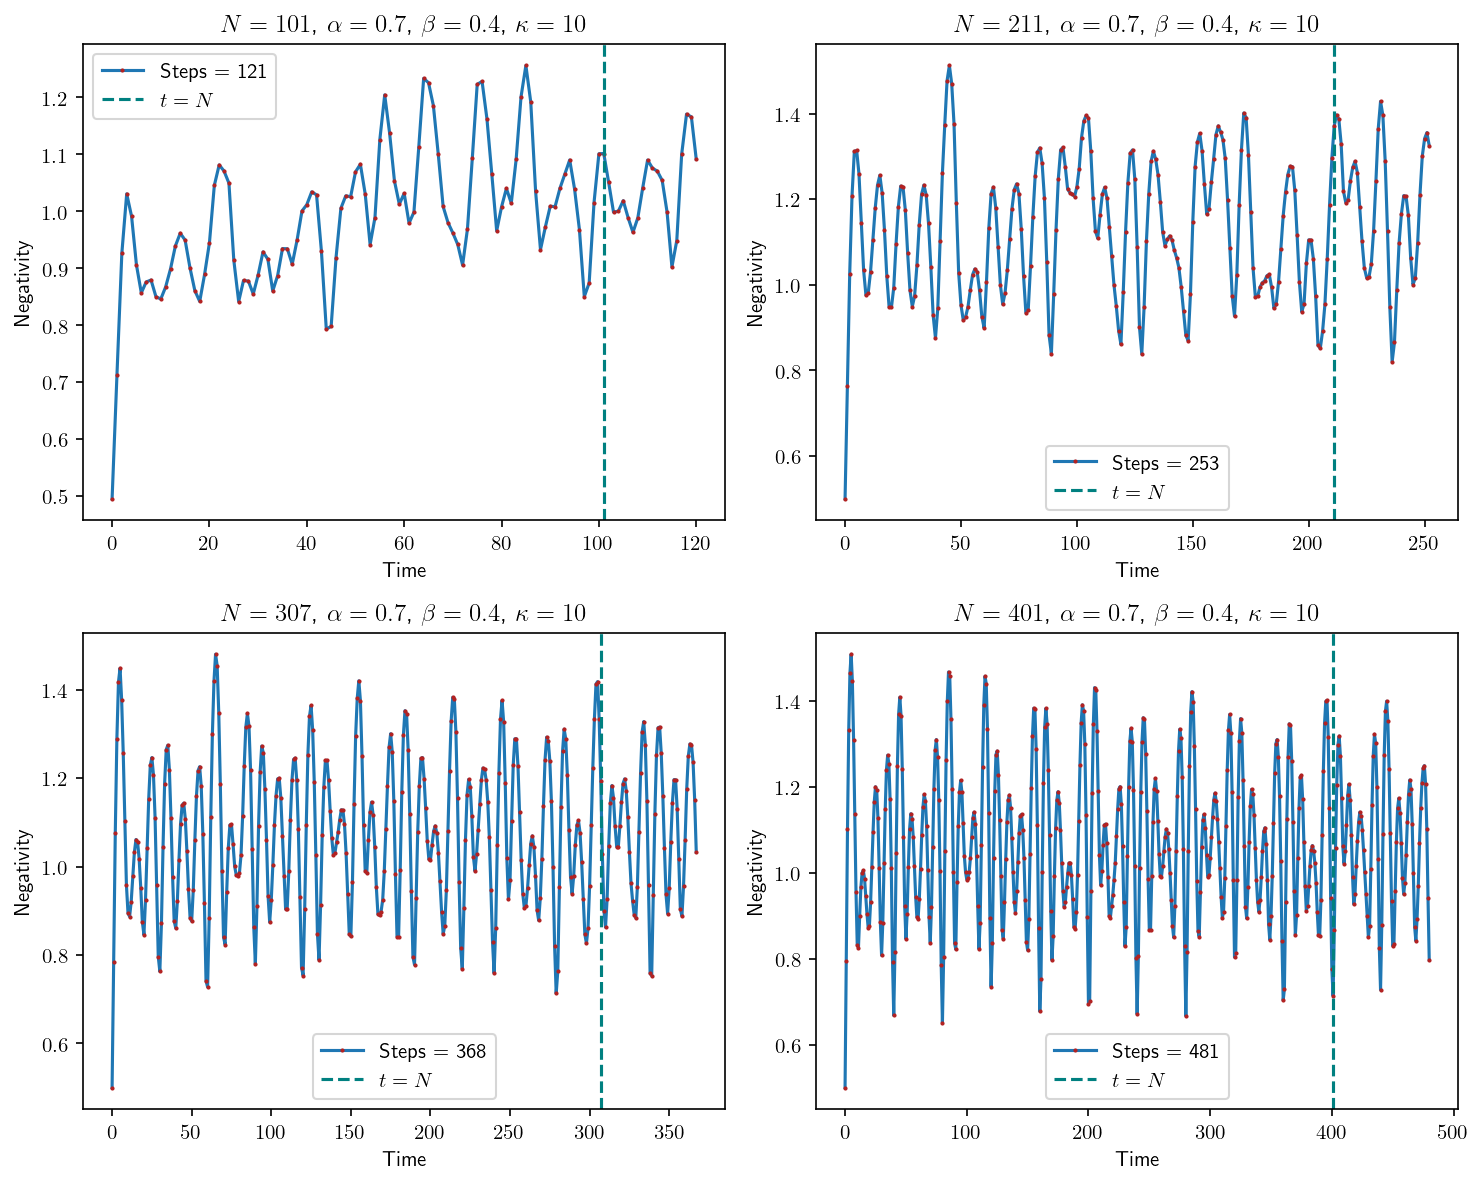

In [11]:
run_time_evolution(Ns_int, 0.7, 0.4, K_int, coherent_state)
run_time_evolution(Ns_int, 0.7, 0.4, 10, coherent_state)

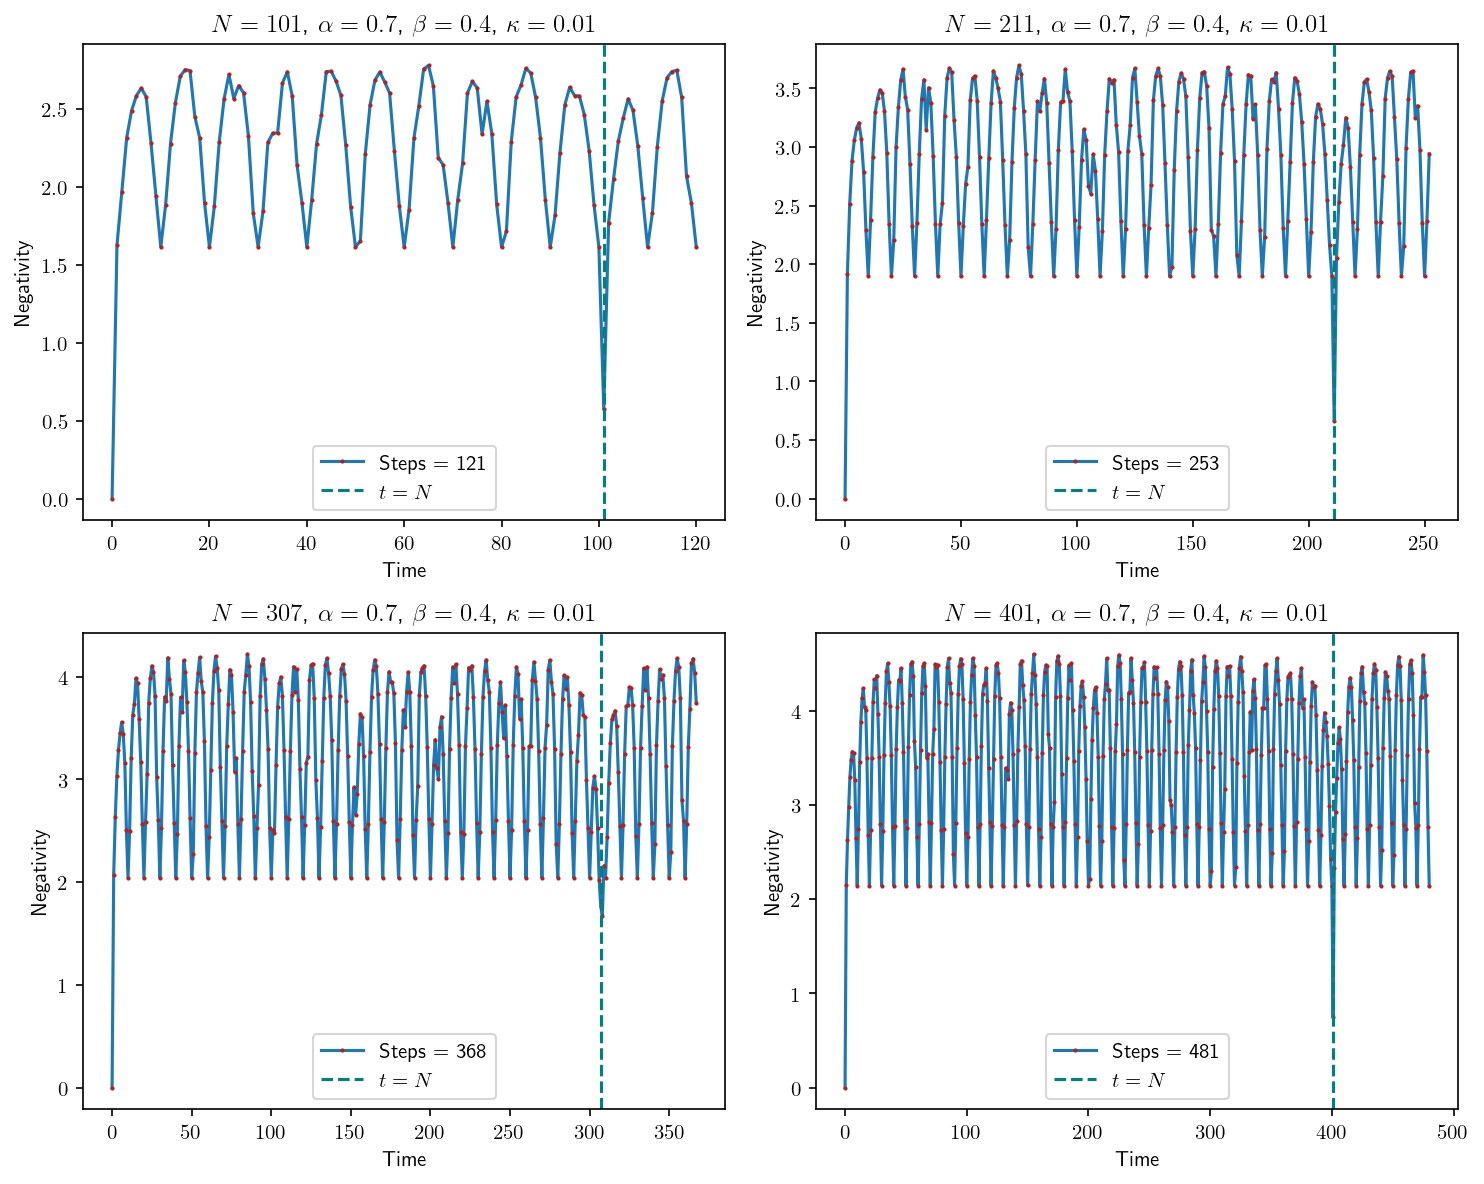

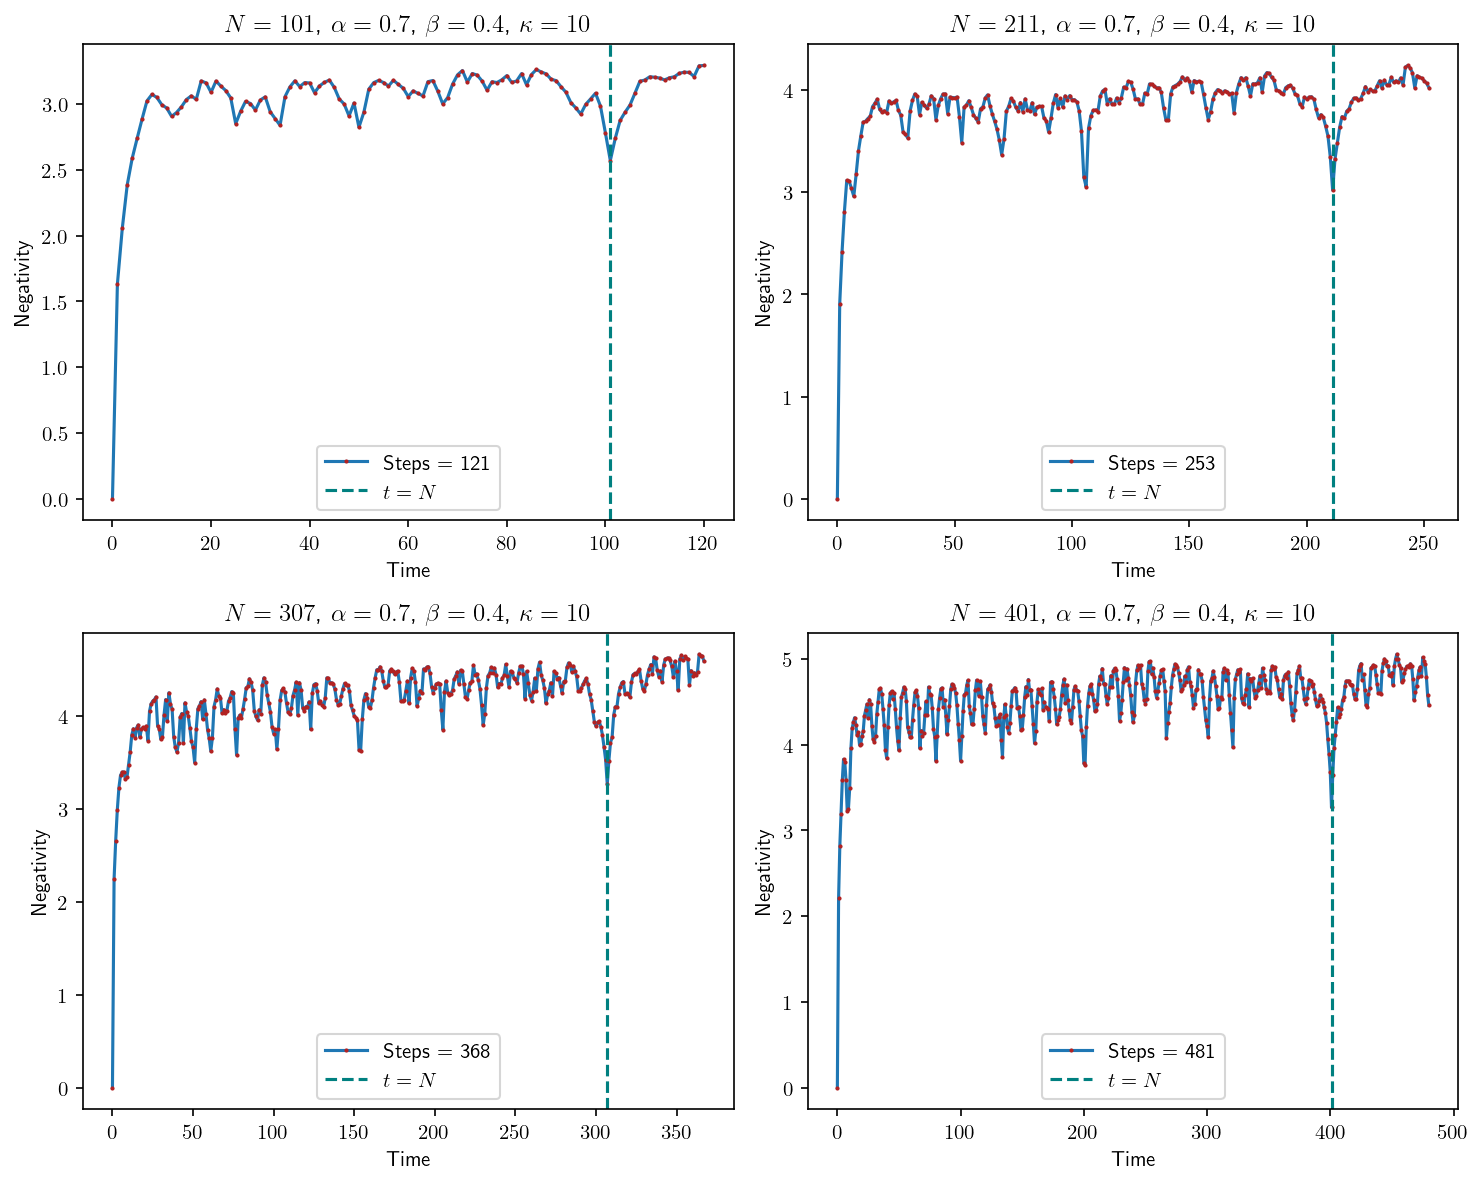

In [12]:
run_time_evolution(Ns_int, 0.7, 0.4, K_int, q_eigenstate)
run_time_evolution(Ns_int, 0.7, 0.4, 10, q_eigenstate)

coupling:   0%|          | 0/101 [00:00<?, ?it/s]

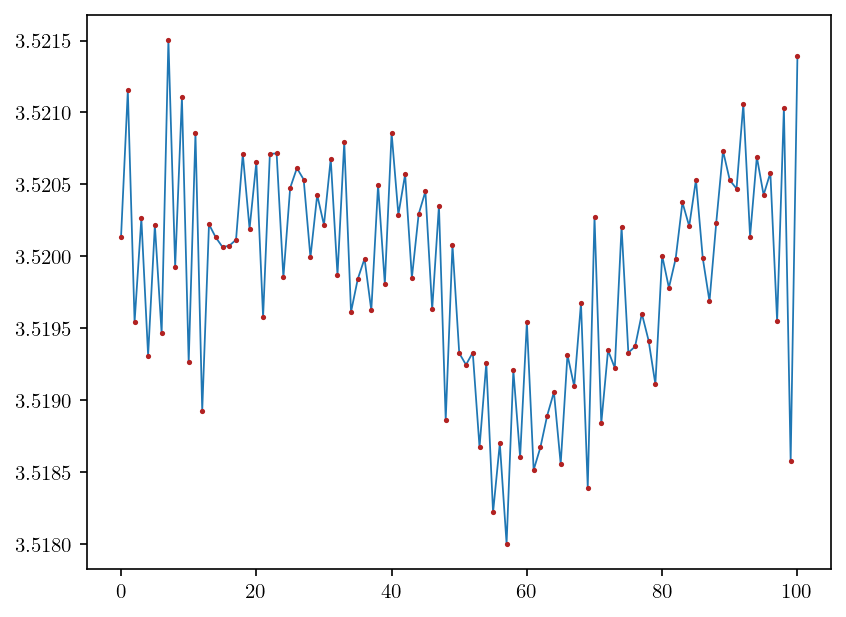

In [19]:
# do averaging for random state

N = 101; 
sum = 0
for i in range(100):
    neg = negativity_time_series(N, 0, 0, 0.01, N, random_state, "rotor")
    sum+=neg
neg_avg = sum/100
plt.plot(np.arange(N), neg_avg, lw = 0.85, marker='o', markersize=1.5, markerfacecolor='firebrick', markeredgecolor='firebrick')
plt.show()

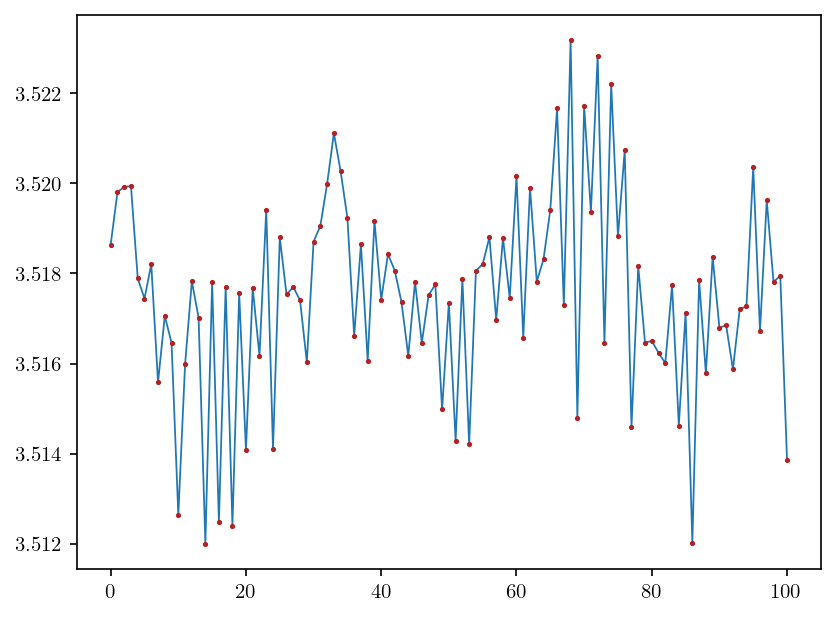

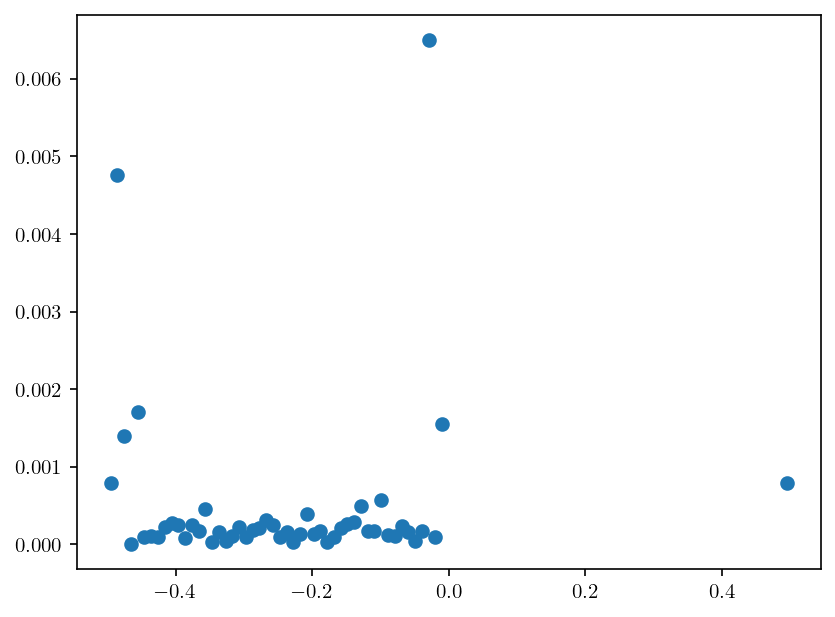

In [31]:
# do averaging for random state

N = 101; 
sum = 0
for i in range(10):
    neg = negativity_time_series(N, 0, 0, 0.01, N, random_state, "rotor")
    sum+=neg
neg_avg = sum/10
plt.plot(np.arange(N), neg_avg, lw = 0.85, marker='o', markersize=1.5, markerfacecolor='firebrick', markeredgecolor='firebrick')
plt.show()

fft = np.fft.fft(neg_avg)
fftfreq = np.fft.fftfreq(N, d = 1)

plt.scatter(fftfreq[N//2:], np.abs(fft[N//2:])**2)
plt.show()

In [21]:
N = 101
alpha = 0; beta = 0
K1 = 0.01; K2 = 10
t = np.arange(N)

In [46]:
def do_time_evolution(N, K, alpha, beta, state, model, title):
    t = np.arange(N)
    neg = negativity_time_series(N, alpha, beta, K, N, state, model)

    plt.plot(t[2:], neg[2:], lw = 0.85, marker='o', markersize=1.5, markerfacecolor='firebrick', markeredgecolor='firebrick')
    plt.xlabel("Kick number (time)")
    plt.ylabel(rf"$\eta(t)$")
    plt.title(title + rf", $N = {N}$, $\kappa = {K}$, $\alpha = {alpha}$, $\beta = {beta}$")
    plt.grid(alpha = 0.2)
    plt.show()

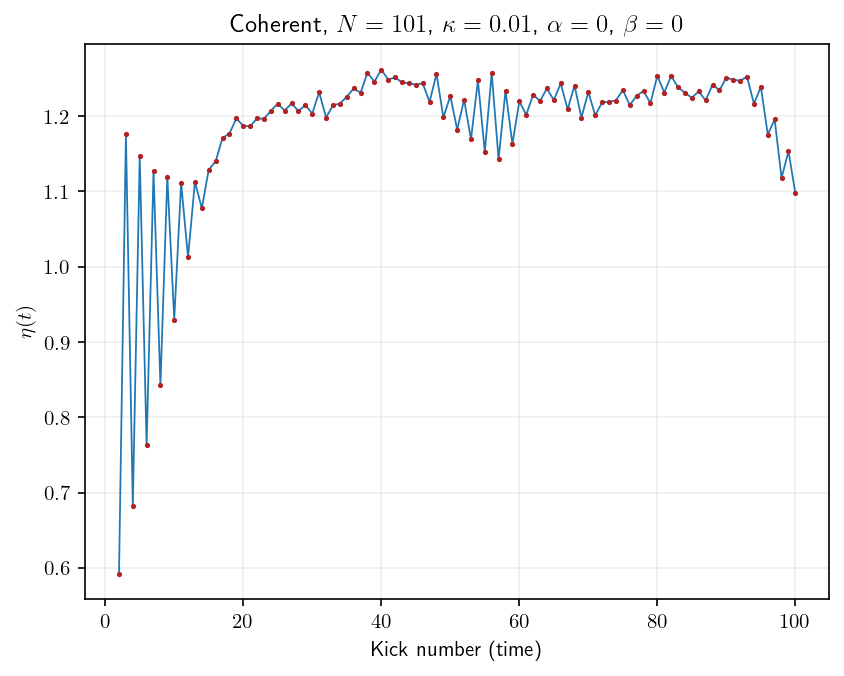

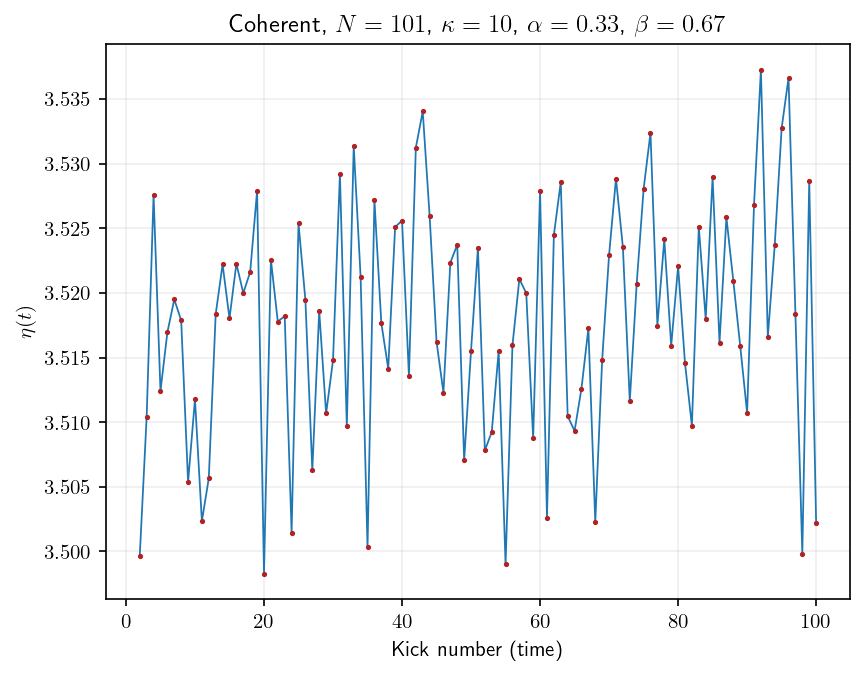

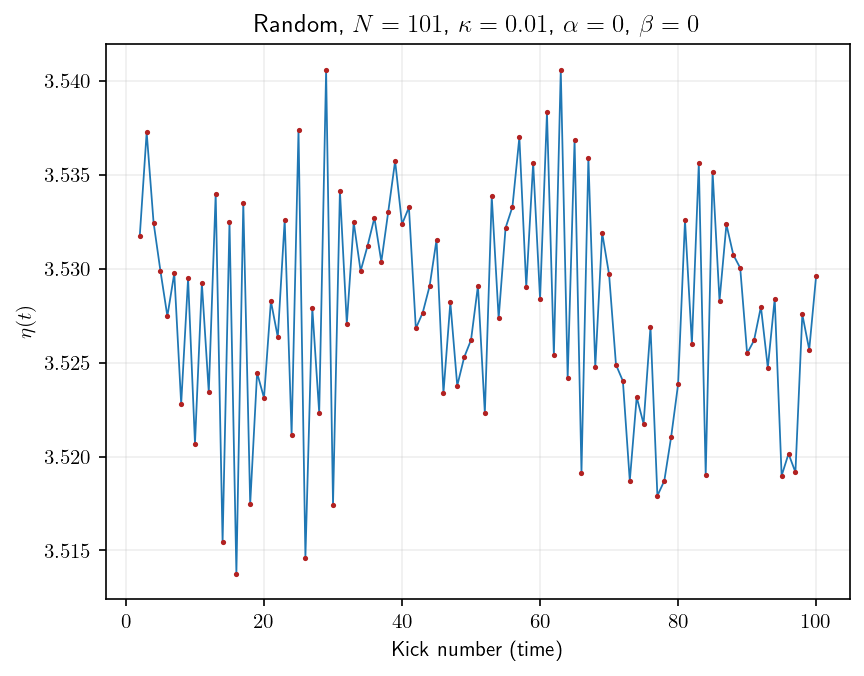

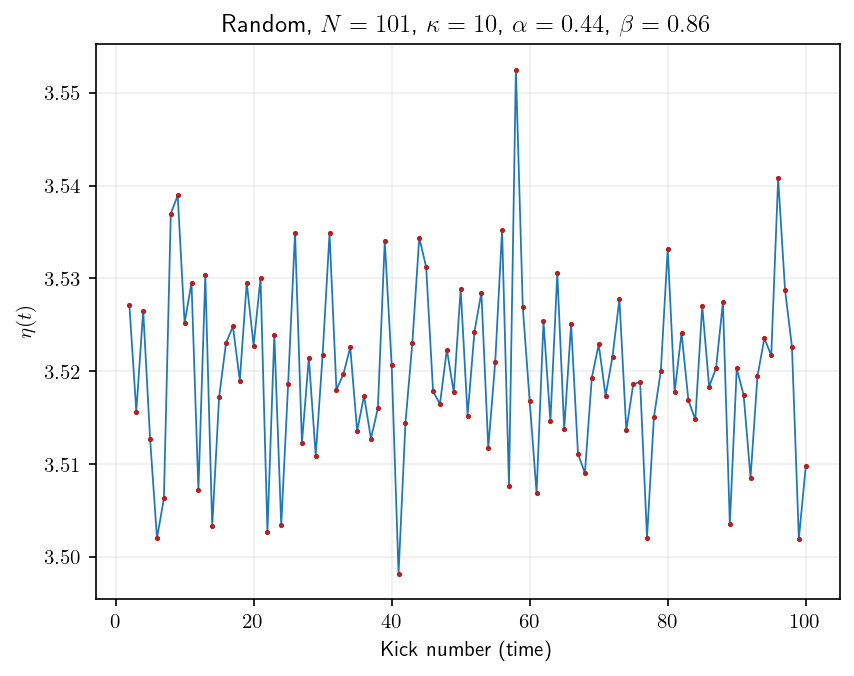

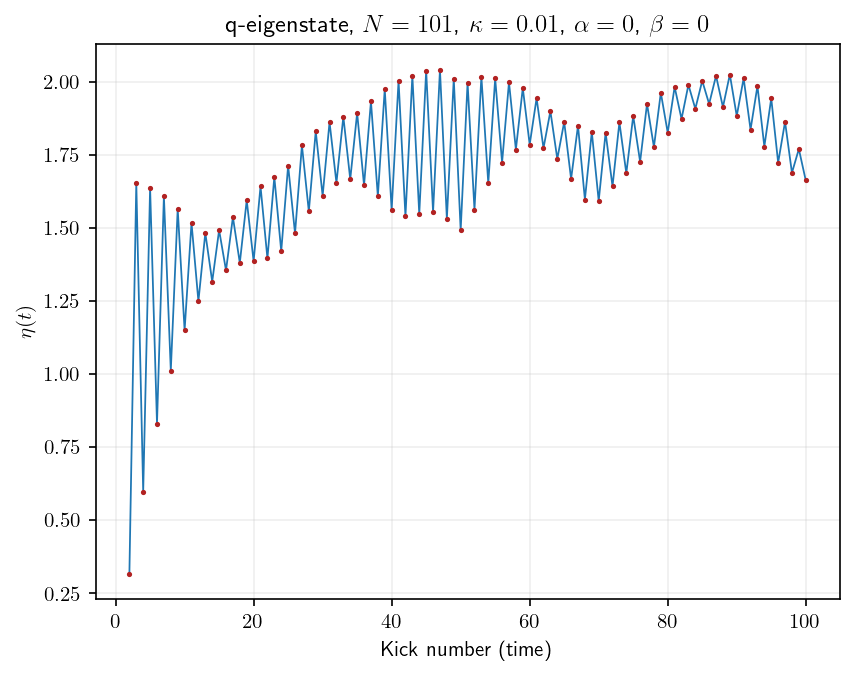

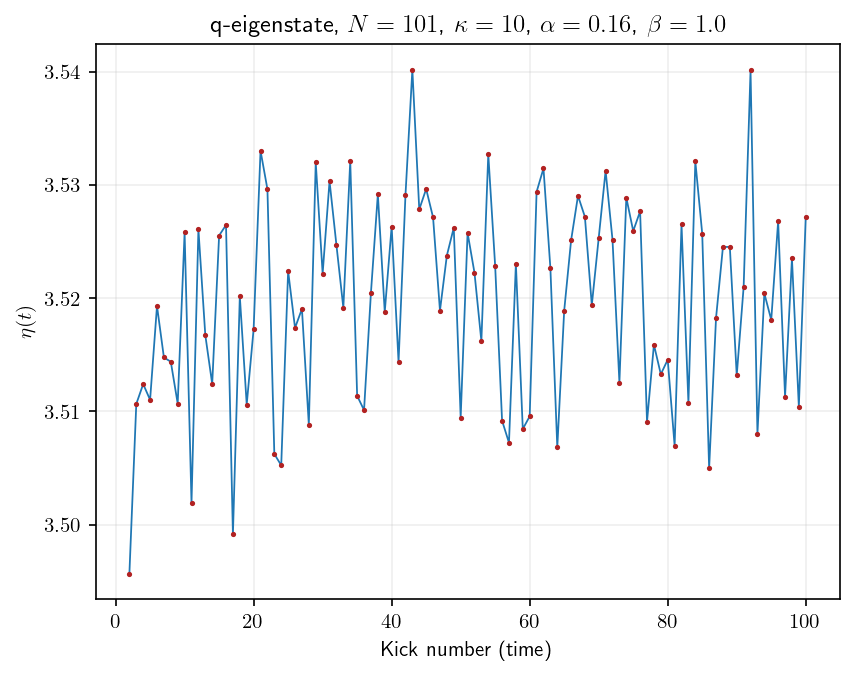

In [49]:
do_time_evolution(N, K1, 0, 0, coherent_state, "rotor", "Coherent")
do_time_evolution(N, K2, 0.33, 0.67, coherent_state, "rotor", "Coherent")
do_time_evolution(N, K1, 0, 0, random_state, "rotor", "Random")
do_time_evolution(N, K2, np.round(np.random.uniform(0, 1),2), np.round(np.random.uniform(0, 1),2), random_state, "rotor", "Random")
do_time_evolution(N, K1, 0, 0, q_eigenstate, "rotor", "q-eigenstate")
do_time_evolution(N, K2, np.round(np.random.uniform(0, 1),2), np.round(np.random.uniform(0, 1),2), q_eigenstate, "rotor", "q-eigenstate")

In [36]:
from scipy.signal import windows


def power_spectrum(neg, detrend=True, window=True):
    """
    Compute the one-sided power spectrum of the negativity time series.
    Returns frequencies (in units of 1/step) and the power.
    """
    n = len(neg)
    signal = neg - np.mean(neg) if detrend else neg

    if window:
        w = windows.hann(n)
        signal = signal * w
        # Normalise for the window power loss
        signal *= n / np.sum(w)

    ft = np.fft.rfft(signal)
    power = (np.abs(ft) ** 2) / n

    # Double all bins except DC and Nyquist to conserve total power
    power[1:-1] *= 2

    freqs = np.fft.rfftfreq(n)   # units: cycles per step
    return freqs, power


def plot_power_spectrum(neg, ax=None, log_scale=True, detrend=True, window=True, label=None):
    """
    Plot the power spectrum of a negativity time series on a given axes.
    If ax is None, creates a new figure.
    """
    freqs, power = power_spectrum(neg, detrend=detrend, window=window)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    if log_scale:
        ax.semilogy(freqs, power, label=label)
    else:
        ax.plot(freqs, power, label=label)

    ax.set_xlabel("Frequency (cycles / kick)")
    ax.set_ylabel("Power")
    ax.set_title("Power spectrum of negativity")
    if label:
        ax.legend()

    return ax

<Axes: title={'center': 'Power spectrum of negativity'}, xlabel='Frequency (cycles / kick)', ylabel='Power'>

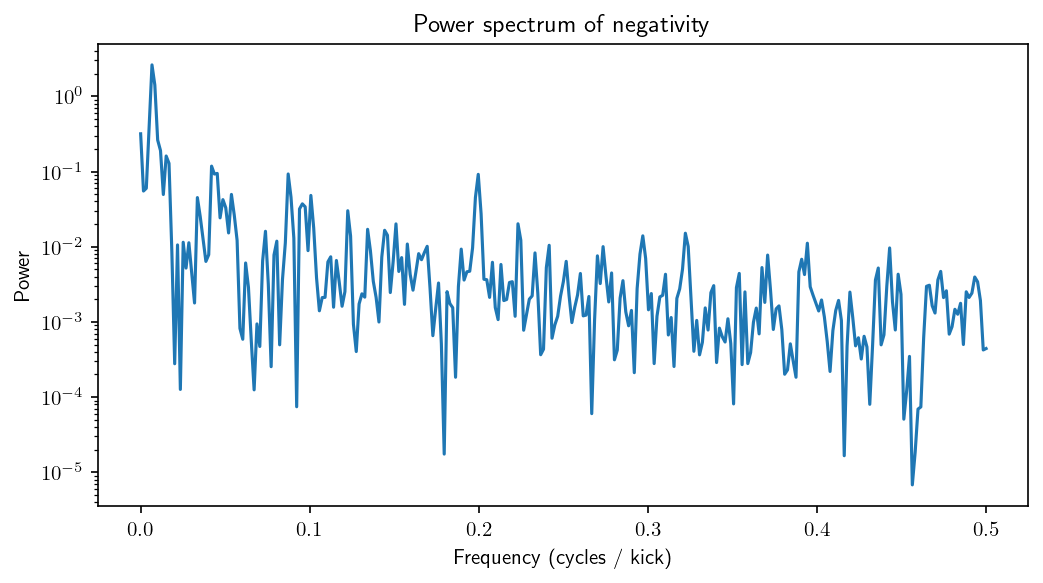

In [42]:
plot_power_spectrum(negativity_time_series(601, 0.3, 0.6, 0.10, 601, coherent_state, "rotor")[5:])

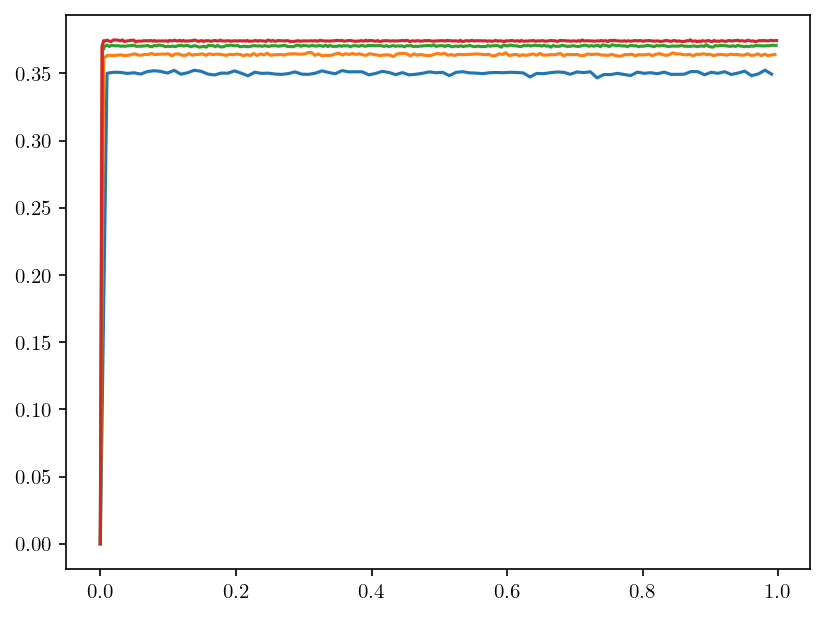

In [16]:
# trying to recreate Basu et al. result on GUE matrix time evolution

for N in [101, 199, 301, 401]:
    neg = negativity_time_series(N, 0.21, 0.64, 10, N, q_eigenstate, "rotor")
    t = np.arange(len(neg))
    plt.plot(t/N, neg/np.sqrt(N))
plt.show()

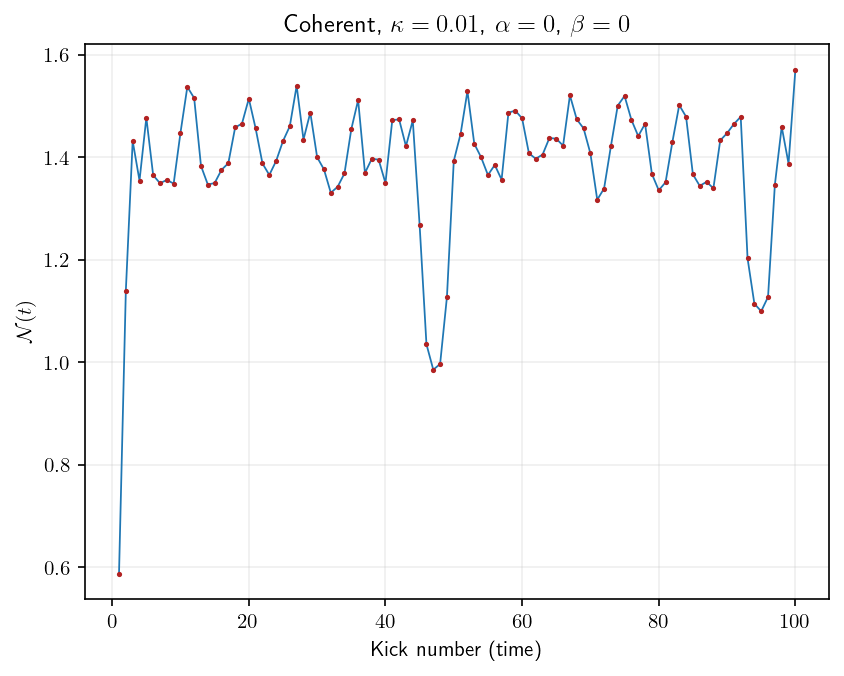

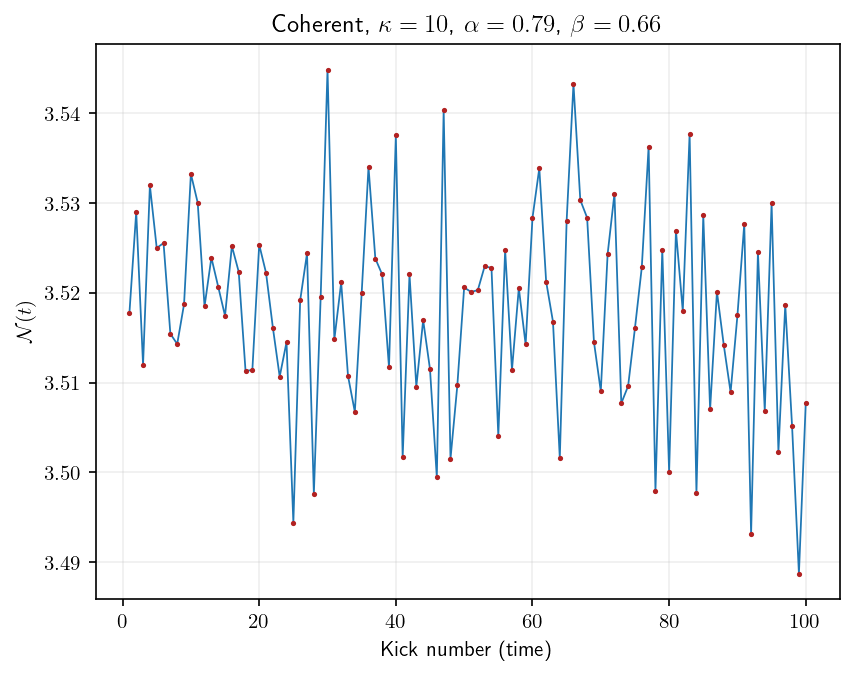

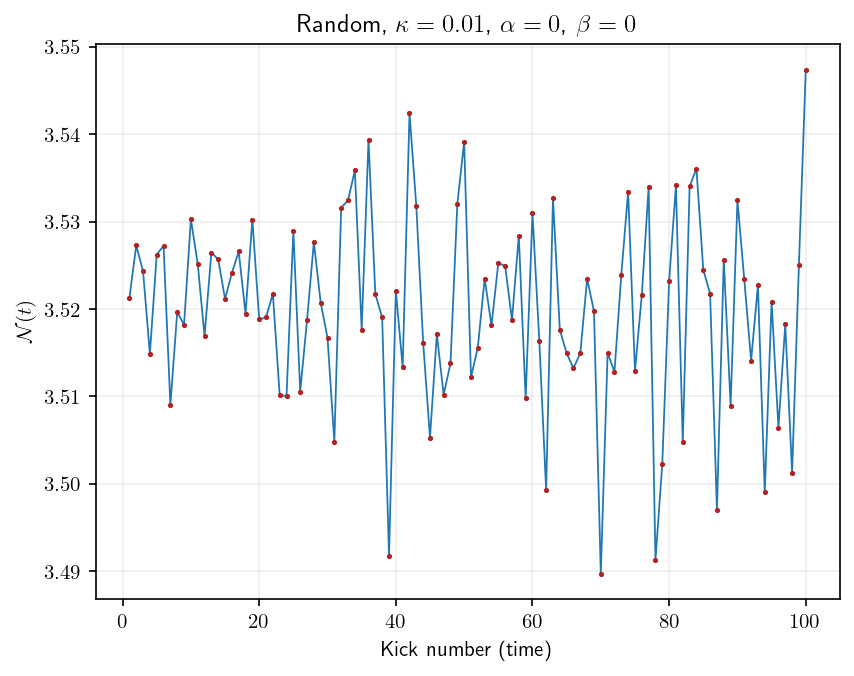

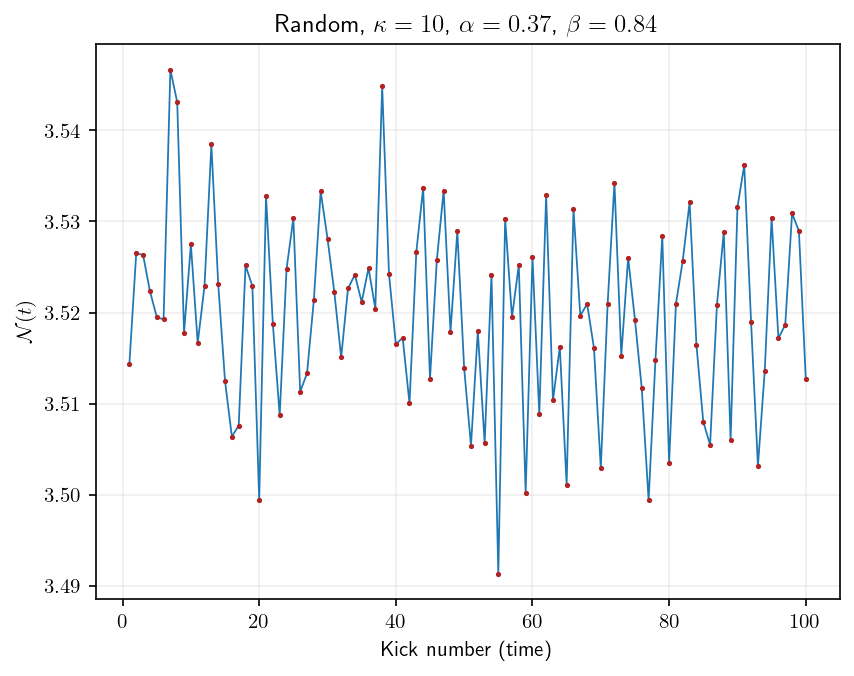

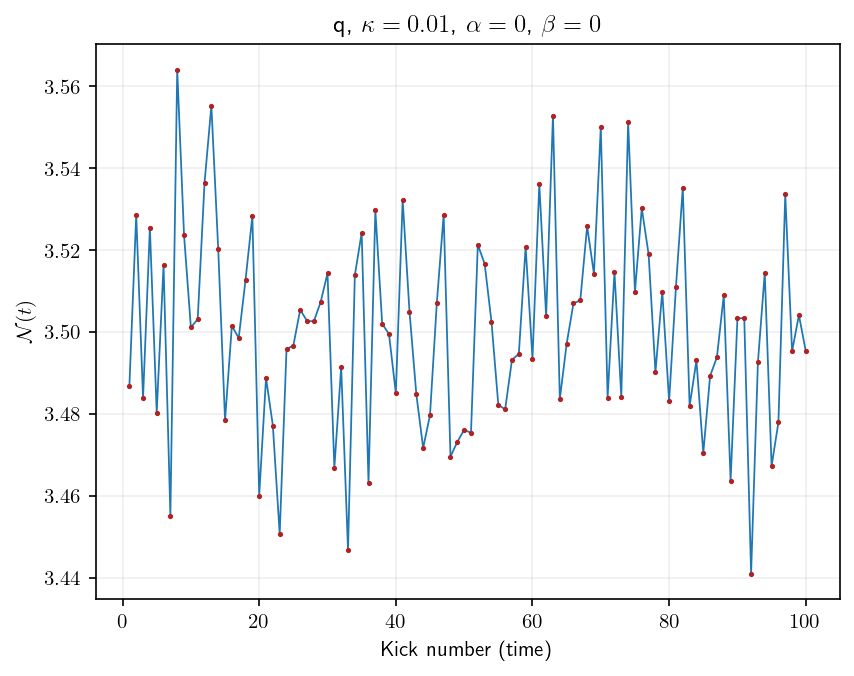

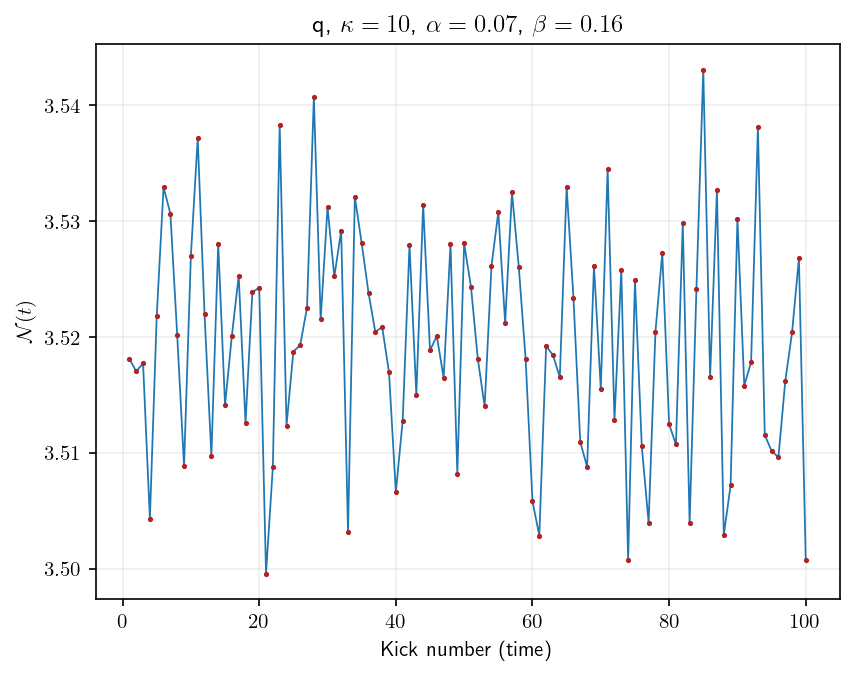

In [8]:
do_time_evolution(N, K1, 0, 0, coherent_state, "harper", "Coherent")
do_time_evolution(N, K2, np.round(np.random.uniform(0, 1),2), np.round(np.random.uniform(0, 1),2), coherent_state, "harper", "Coherent")
do_time_evolution(N, K1, 0, 0, random_state, "harper", "Random")
do_time_evolution(N, K2, np.round(np.random.uniform(0, 1),2), np.round(np.random.uniform(0, 1),2), random_state, "harper", "Random")
do_time_evolution(N, K1, 0, 0, q_eigenstate, "harper", "q")
do_time_evolution(N, K2, np.round(np.random.uniform(0, 1),2), np.round(np.random.uniform(0, 1),2), q_eigenstate, "harper", "q")